# 🚗 EV Data Analytics — SQLite SQL Complete Book

## 200 SQL Commands | Basic → Intermediate → Advanced → Deep Business Analysis

**Database:** `datas/database/ev_analysis.db`  
**Table:** `ev_vehicles`

This notebook is designed as a practical Data Analyst SQL project using the actual EV dataset columns.

In [1]:
import sqlite3
import pandas as pd
from pathlib import Path

# ============================================================
# SQLite Database Connection
# ============================================================

# Notebook is inside:
# D:\ev_project_v2-Data Analysis\notebooks

ROOT = Path("..").resolve()

DB_PATH = ROOT / "datas" / "database" / "ev_analysis.db"

print("Database path:")
print(DB_PATH)

# Check database
if not DB_PATH.exists():
    raise FileNotFoundError(
        f"""
Database not found!

Expected location:
{DB_PATH}

Please create the database first using the CSV → SQLite cell.
"""
    )

# Connect
conn = sqlite3.connect(DB_PATH)

print("\n✅ SQLite connected successfully!")
print("Database:", DB_PATH)

Database path:
D:\ev_project_v2-Data Analysis\datas\database\ev_analysis.db

✅ SQLite connected successfully!
Database: D:\ev_project_v2-Data Analysis\datas\database\ev_analysis.db


## Dataset & schema check

Before analysis, verify the database, table, row count, and columns. This prevents the `KeyError` problems caused by using columns that do not exist in the dataset.

In [2]:
display(pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn))
display(pd.read_sql_query("PRAGMA table_info(ev_vehicles);", conn))
display(pd.read_sql_query("SELECT COUNT(*) AS total_records FROM ev_vehicles;", conn))
display(pd.read_sql_query("SELECT * FROM ev_vehicles LIMIT 10;", conn))

,name
0,ev_vehicles


,cid,name,type,notnull,dflt_value,pk
0,0,VIN,TEXT,0,None,0
1,1,County,TEXT,0,None,0
2,2,City,TEXT,0,None,0
3,3,State,TEXT,0,None,0
4,4,Postal_Code,REAL,0,None,0
...,...,...,...,...,...,...
63,63,Has_Census_Tract,INTEGER,0,None,0
64,64,Has_Legislative_District,INTEGER,0,None,0
65,65,Has_VIN,INTEGER,0,None,0
66,66,Missing_Features_Count,INTEGER,0,None,0


,total_records
0,150482


,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,...,City_EV_Count,Utility_EV_Count,CAFV_Eligible_Flag,CAFV_Status,Has_Location,Has_Census_Tract,Has_Legislative_District,Has_VIN,Missing_Features_Count,Data_Completeness_Pct
0,KM8K33AGXL,King,Seattle,WA,98103.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,25678,27268,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
1,1C4RJYB61N,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,4861,55637,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
2,1C4RJYD61P,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,552,1102,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
3,5YJ3E1EA7J,King,Kirkland,WA,98034.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,4622,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
4,WBY7Z8C5XJ,Thurston,Olympia,WA,98501.0,2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,...,3634,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
5,5YJ3E1EAXL,Snohomish,Marysville,WA,98271.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,955,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
6,2C4RC1N77H,King,Kent,WA,98042.0,2017,CHRYSLER,PACIFICA,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,...,2276,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
7,5YJYGDEE3L,King,Woodinville,WA,98072.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,2024,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
8,5YJ3E1EA1J,Island,Coupeville,WA,98239.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,197,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
9,7SAYGDEF0P,King,Bellevue,WA,98004.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,...,7691,55637,0,Eligibility unknown as battery range has not b...,1,1,1,1,4,94.029851


# 2. SQL COMMANDS — BASIC (1–50)

Run each query, inspect the output, and write one business observation in your notes.

### 1. SELECT all records
**Level:** Basic

In [3]:
result = pd.read_sql_query("""SELECT * FROM ev_vehicles LIMIT 20;""", conn)
display(result)

,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,...,City_EV_Count,Utility_EV_Count,CAFV_Eligible_Flag,CAFV_Status,Has_Location,Has_Census_Tract,Has_Legislative_District,Has_VIN,Missing_Features_Count,Data_Completeness_Pct
0,KM8K33AGXL,King,Seattle,WA,98103.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,25678,27268,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
1,1C4RJYB61N,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,4861,55637,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
2,1C4RJYD61P,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,552,1102,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
3,5YJ3E1EA7J,King,Kirkland,WA,98034.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,4622,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
4,WBY7Z8C5XJ,Thurston,Olympia,WA,98501.0,2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,...,3634,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
5,5YJ3E1EAXL,Snohomish,Marysville,WA,98271.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,955,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
6,2C4RC1N77H,King,Kent,WA,98042.0,2017,CHRYSLER,PACIFICA,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,...,2276,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
7,5YJYGDEE3L,King,Woodinville,WA,98072.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,2024,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
8,5YJ3E1EA1J,Island,Coupeville,WA,98239.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,197,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
9,7SAYGDEF0P,King,Bellevue,WA,98004.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,...,7691,55637,0,Eligibility unknown as battery range has not b...,1,1,1,1,4,94.029851


### 2. Select core columns
**Level:** Basic

In [4]:
result = pd.read_sql_query("""SELECT VIN, Make, Model, Model_Year, EV_Type FROM ev_vehicles LIMIT 20;""", conn)
display(result)

,VIN,Make,Model,Model_Year,EV_Type
0,KM8K33AGXL,HYUNDAI,KONA,2020,Battery Electric Vehicle (BEV)
1,1C4RJYB61N,JEEP,GRAND CHEROKEE,2022,Plug-in Hybrid Electric Vehicle (PHEV)
2,1C4RJYD61P,JEEP,GRAND CHEROKEE,2023,Plug-in Hybrid Electric Vehicle (PHEV)
3,5YJ3E1EA7J,TESLA,MODEL 3,2018,Battery Electric Vehicle (BEV)
4,WBY7Z8C5XJ,BMW,I3,2018,Plug-in Hybrid Electric Vehicle (PHEV)
5,5YJ3E1EAXL,TESLA,MODEL 3,2020,Battery Electric Vehicle (BEV)
6,2C4RC1N77H,CHRYSLER,PACIFICA,2017,Plug-in Hybrid Electric Vehicle (PHEV)
7,5YJYGDEE3L,TESLA,MODEL Y,2020,Battery Electric Vehicle (BEV)
8,5YJ3E1EA1J,TESLA,MODEL 3,2018,Battery Electric Vehicle (BEV)
9,7SAYGDEF0P,TESLA,MODEL Y,2023,Battery Electric Vehicle (BEV)


### 3. Select location columns
**Level:** Basic

In [5]:
result = pd.read_sql_query("""SELECT County, City, State, Postal_Code FROM ev_vehicles LIMIT 20;""", conn)
display(result)

,County,City,State,Postal_Code
0,King,Seattle,WA,98103.0
1,King,Bothell,WA,98011.0
2,Yakima,Yakima,WA,98908.0
3,King,Kirkland,WA,98034.0
4,Thurston,Olympia,WA,98501.0
5,Snohomish,Marysville,WA,98271.0
6,King,Kent,WA,98042.0
7,King,Woodinville,WA,98072.0
8,Island,Coupeville,WA,98239.0
9,King,Bellevue,WA,98004.0


### 4. Select EV specifications
**Level:** Basic

In [6]:
result = pd.read_sql_query("""SELECT Make, Model, EV_Type, Electric_Range, Base_MSRP FROM ev_vehicles LIMIT 20;""", conn)
display(result)

,Make,Model,EV_Type,Electric_Range,Base_MSRP
0,HYUNDAI,KONA,Battery Electric Vehicle (BEV),258,0
1,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),25,0
2,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),25,0
3,TESLA,MODEL 3,Battery Electric Vehicle (BEV),215,0
4,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),97,0
5,TESLA,MODEL 3,Battery Electric Vehicle (BEV),266,0
6,CHRYSLER,PACIFICA,Plug-in Hybrid Electric Vehicle (PHEV),33,0
7,TESLA,MODEL Y,Battery Electric Vehicle (BEV),291,0
8,TESLA,MODEL 3,Battery Electric Vehicle (BEV),215,0
9,TESLA,MODEL Y,Battery Electric Vehicle (BEV),0,0


### 5. Distinct EV types
**Level:** Basic

In [7]:
result = pd.read_sql_query("""SELECT DISTINCT EV_Type FROM ev_vehicles ORDER BY EV_Type;""", conn)
display(result)

,EV_Type
0,Battery Electric Vehicle (BEV)
1,Plug-in Hybrid Electric Vehicle (PHEV)


### 6. Distinct manufacturers
**Level:** Basic

In [8]:
result = pd.read_sql_query("""SELECT DISTINCT Make FROM ev_vehicles ORDER BY Make;""", conn)
display(result)

,Make
0,ALFA ROMEO
1,AUDI
2,AZURE DYNAMICS
3,BENTLEY
4,BMW
5,CADILLAC
6,CHEVROLET
7,CHRYSLER
8,FIAT
9,FISKER


### 7. Distinct states
**Level:** Basic

In [9]:
result = pd.read_sql_query("""SELECT DISTINCT State FROM ev_vehicles ORDER BY State;""", conn)
display(result)

,State
0,AK
1,AL
2,AP
3,AR
4,AZ
5,BC
6,CA
7,CO
8,CT
9,DC


### 8. Count records
**Level:** Basic

In [10]:
result = pd.read_sql_query("""SELECT COUNT(*) AS total_records FROM ev_vehicles;""", conn)
display(result)

,total_records
0,150482


### 9. Count VINs
**Level:** Basic

In [11]:
result = pd.read_sql_query("""SELECT COUNT(VIN) AS vin_count FROM ev_vehicles;""", conn)
display(result)

,vin_count
0,150482


### 10. Distinct models
**Level:** Basic

In [12]:
result = pd.read_sql_query("""SELECT COUNT(DISTINCT Model) AS distinct_models FROM ev_vehicles;""", conn)
display(result)

,distinct_models
0,127


### 11. Distinct manufacturers count
**Level:** Basic

In [13]:
result = pd.read_sql_query("""SELECT COUNT(DISTINCT Make) AS manufacturers FROM ev_vehicles;""", conn)
display(result)

,manufacturers
0,37


### 12. Distinct states count
**Level:** Basic

In [14]:
result = pd.read_sql_query("""SELECT COUNT(DISTINCT State) AS states FROM ev_vehicles;""", conn)
display(result)

,states
0,41


### 13. Latest model year
**Level:** Basic

In [15]:
result = pd.read_sql_query("""SELECT MAX(Model_Year) AS latest_year FROM ev_vehicles;""", conn)
display(result)

,latest_year
0,2024


### 14. Earliest model year
**Level:** Basic

In [16]:
result = pd.read_sql_query("""SELECT MIN(Model_Year) AS earliest_year FROM ev_vehicles;""", conn)
display(result)

,earliest_year
0,1997


### 15. Average range
**Level:** Basic

In [17]:
result = pd.read_sql_query("""SELECT ROUND(AVG(Electric_Range),2) AS avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL;""", conn)
display(result)

,avg_range
0,67.88


### 16. Maximum range
**Level:** Basic

In [18]:
result = pd.read_sql_query("""SELECT MAX(Electric_Range) AS max_range FROM ev_vehicles;""", conn)
display(result)

,max_range
0,337


### 17. Minimum positive range
**Level:** Basic

In [19]:
result = pd.read_sql_query("""SELECT MIN(Electric_Range) AS min_range FROM ev_vehicles WHERE Electric_Range>0;""", conn)
display(result)

,min_range
0,6


### 18. Average MSRP
**Level:** Basic

In [20]:
result = pd.read_sql_query("""SELECT ROUND(AVG(Base_MSRP),2) AS avg_msrp FROM ev_vehicles WHERE Base_MSRP>0;""", conn)
display(result)

,avg_msrp
0,57172.04


### 19. Maximum MSRP
**Level:** Basic

In [21]:
result = pd.read_sql_query("""SELECT MAX(Base_MSRP) AS max_msrp FROM ev_vehicles;""", conn)
display(result)

,max_msrp
0,845000


### 20. Minimum positive MSRP
**Level:** Basic

In [22]:
result = pd.read_sql_query("""SELECT MIN(Base_MSRP) AS min_msrp FROM ev_vehicles WHERE Base_MSRP>0;""", conn)
display(result)

,min_msrp
0,31950


### 21. Sort by range
**Level:** Basic

In [23]:
result = pd.read_sql_query("""SELECT Make,Model,Electric_Range FROM ev_vehicles ORDER BY Electric_Range DESC LIMIT 20;""", conn)
display(result)

,Make,Model,Electric_Range
0,TESLA,MODEL S,337
1,TESLA,MODEL S,337
2,TESLA,MODEL S,337
3,TESLA,MODEL S,337
4,TESLA,MODEL S,337
5,TESLA,MODEL S,337
6,TESLA,MODEL S,337
7,TESLA,MODEL S,337
8,TESLA,MODEL S,337
9,TESLA,MODEL S,337


### 22. Sort by MSRP
**Level:** Basic

In [24]:
result = pd.read_sql_query("""SELECT Make,Model,Base_MSRP FROM ev_vehicles ORDER BY Base_MSRP DESC LIMIT 20;""", conn)
display(result)

,Make,Model,Base_MSRP
0,PORSCHE,918,845000
1,PORSCHE,PANAMERA,184400
2,PORSCHE,PANAMERA,184400
3,PORSCHE,PANAMERA,184400
4,PORSCHE,PANAMERA,184400
5,PORSCHE,PANAMERA,184400
6,PORSCHE,PANAMERA,184400
7,PORSCHE,PANAMERA,184400
8,PORSCHE,PANAMERA,184400
9,PORSCHE,PANAMERA,184400


### 23. Sort by model year
**Level:** Basic

In [25]:
result = pd.read_sql_query("""SELECT Make,Model,Model_Year FROM ev_vehicles ORDER BY Model_Year DESC LIMIT 20;""", conn)
display(result)

,Make,Model,Model_Year
0,CADILLAC,LYRIQ,2024
1,JEEP,WRANGLER,2024
2,BMW,X5,2024
3,BMW,X5,2024
4,VOLVO,XC60,2024
5,BMW,IX,2024
6,BMW,X5,2024
7,BMW,IX,2024
8,BMW,IX,2024
9,LEXUS,NX,2024


### 24. BEV records
**Level:** Basic

In [26]:
result = pd.read_sql_query("""SELECT * FROM ev_vehicles WHERE Is_BEV=1 LIMIT 20;""", conn)
display(result)

,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,...,City_EV_Count,Utility_EV_Count,CAFV_Eligible_Flag,CAFV_Status,Has_Location,Has_Census_Tract,Has_Legislative_District,Has_VIN,Missing_Features_Count,Data_Completeness_Pct
0,KM8K33AGXL,King,Seattle,WA,98103.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,25678,27268,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
1,5YJ3E1EA7J,King,Kirkland,WA,98034.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,4622,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
2,5YJ3E1EAXL,Snohomish,Marysville,WA,98271.0,2020,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,955,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
3,5YJYGDEE3L,King,Woodinville,WA,98072.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,2024,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
4,5YJ3E1EA1J,Island,Coupeville,WA,98239.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,197,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
5,7SAYGDEF0P,King,Bellevue,WA,98004.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,...,7691,55637,0,Eligibility unknown as battery range has not b...,1,1,1,1,4,94.029851
6,5YJ3E1EA7J,King,Kirkland,WA,98033.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,4622,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
7,5YJ3E1EB8K,Snohomish,Mukilteo,WA,98275.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,661,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
8,5YJ3E1EA5K,King,Redmond,WA,98052.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,5502,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
9,WA1VABGE4K,King,Seattle,WA,98112.0,2019,AUDI,E-TRON,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,25678,27268,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388


### 25. PHEV records
**Level:** Basic

In [27]:
result = pd.read_sql_query("""SELECT * FROM ev_vehicles WHERE Is_PHEV=1 LIMIT 20;""", conn)
display(result)

,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,...,City_EV_Count,Utility_EV_Count,CAFV_Eligible_Flag,CAFV_Status,Has_Location,Has_Census_Tract,Has_Legislative_District,Has_VIN,Missing_Features_Count,Data_Completeness_Pct
0,1C4RJYB61N,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,4861,55637,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
1,1C4RJYD61P,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,552,1102,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
2,WBY7Z8C5XJ,Thurston,Olympia,WA,98501.0,2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,...,3634,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
3,2C4RC1N77H,King,Kent,WA,98042.0,2017,CHRYSLER,PACIFICA,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,...,2276,55637,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388
4,3FA6P0SU9G,Kitsap,Port Orchard,WA,98367.0,2016,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,881,29865,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
5,JTDKARFP9H,Kitsap,Port Orchard,WA,98366.0,2017,TOYOTA,PRIUS PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,881,29865,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
6,3FA6P0SU0D,Thurston,Rochester,WA,98579.0,2013,FORD,FUSION,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,99,29865,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
7,KNDCC3LD7K,Kitsap,Bremerton,WA,98311.0,2019,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,1028,29865,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
8,5UXKT0C51J,King,Kent,WA,98042.0,2018,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,2276,55637,1,Not eligible due to low battery range,1,1,1,1,3,95.522388
9,1G1RB6E46D,Kitsap,Bremerton,WA,98312.0,2013,CHEVROLET,VOLT,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,...,1028,29865,1,Clean Alternative Fuel Vehicle Eligible,1,1,1,1,3,95.522388


### 26. Range above 300
**Level:** Basic

In [28]:
result = pd.read_sql_query("""SELECT Make,Model,Electric_Range FROM ev_vehicles WHERE Electric_Range>300 ORDER BY Electric_Range DESC;""", conn)
display(result)

,Make,Model,Electric_Range
0,TESLA,MODEL S,337
1,TESLA,MODEL S,337
2,TESLA,MODEL S,337
3,TESLA,MODEL S,337
4,TESLA,MODEL S,337
...,...,...,...
2654,TESLA,MODEL 3,308
2655,TESLA,MODEL 3,308
2656,TESLA,MODEL 3,308
2657,TESLA,MODEL 3,308


### 27. Range 200 to 300
**Level:** Basic

In [29]:
result = pd.read_sql_query("""SELECT Make,Model,Electric_Range FROM ev_vehicles WHERE Electric_Range BETWEEN 200 AND 300 ORDER BY Electric_Range DESC;""", conn)
display(result)

,Make,Model,Electric_Range
0,TESLA,MODEL X,293
1,TESLA,MODEL X,293
2,TESLA,MODEL X,293
3,TESLA,MODEL X,293
4,TESLA,MODEL X,293
...,...,...,...
29331,TESLA,MODEL X,200
29332,TESLA,MODEL X,200
29333,TESLA,MODEL X,200
29334,TESLA,MODEL X,200


### 28. MSRP above 50K
**Level:** Basic

In [30]:
result = pd.read_sql_query("""SELECT Make,Model,Base_MSRP FROM ev_vehicles WHERE Base_MSRP>50000 ORDER BY Base_MSRP DESC;""", conn)
display(result)

,Make,Model,Base_MSRP
0,PORSCHE,918,845000
1,PORSCHE,PANAMERA,184400
2,PORSCHE,PANAMERA,184400
3,PORSCHE,PANAMERA,184400
4,PORSCHE,PANAMERA,184400
...,...,...,...
2296,BMW,530E,52650
2297,BMW,530E,52650
2298,BMW,530E,52650
2299,BMW,530E,52650


### 29. Models from 2020
**Level:** Basic

In [31]:
result = pd.read_sql_query("""SELECT Make,Model,Model_Year FROM ev_vehicles WHERE Model_Year>=2020 ORDER BY Model_Year;""", conn)
display(result)

,Make,Model,Model_Year
0,HYUNDAI,KONA,2020
1,TESLA,MODEL 3,2020
2,TESLA,MODEL Y,2020
3,TESLA,MODEL 3,2020
4,TESLA,MODEL S,2020
...,...,...,...
95493,BMW,IX,2024
95494,BMW,X5,2024
95495,VOLVO,V60,2024
95496,AUDI,Q8,2024


### 30. Washington records
**Level:** Basic

In [32]:
result = pd.read_sql_query("""SELECT City,State,Make,Model FROM ev_vehicles WHERE State='WA' LIMIT 20;""", conn)
display(result)

,City,State,Make,Model
0,Seattle,WA,HYUNDAI,KONA
1,Bothell,WA,JEEP,GRAND CHEROKEE
2,Yakima,WA,JEEP,GRAND CHEROKEE
3,Kirkland,WA,TESLA,MODEL 3
4,Olympia,WA,BMW,I3
5,Marysville,WA,TESLA,MODEL 3
6,Kent,WA,CHRYSLER,PACIFICA
7,Woodinville,WA,TESLA,MODEL Y
8,Coupeville,WA,TESLA,MODEL 3
9,Bellevue,WA,TESLA,MODEL Y


### 31. Tesla records
**Level:** Basic

In [33]:
result = pd.read_sql_query("""SELECT Model,Model_Year,EV_Type,Electric_Range FROM ev_vehicles WHERE Make='TESLA' LIMIT 20;""", conn)
display(result)

,Model,Model_Year,EV_Type,Electric_Range
0,MODEL 3,2018,Battery Electric Vehicle (BEV),215
1,MODEL 3,2020,Battery Electric Vehicle (BEV),266
2,MODEL Y,2020,Battery Electric Vehicle (BEV),291
3,MODEL 3,2018,Battery Electric Vehicle (BEV),215
4,MODEL Y,2023,Battery Electric Vehicle (BEV),0
5,MODEL 3,2018,Battery Electric Vehicle (BEV),215
6,MODEL 3,2019,Battery Electric Vehicle (BEV),220
7,MODEL 3,2019,Battery Electric Vehicle (BEV),220
8,MODEL S,2018,Battery Electric Vehicle (BEV),249
9,MODEL 3,2020,Battery Electric Vehicle (BEV),322


### 32. Models containing Model
**Level:** Basic

In [34]:
result = pd.read_sql_query("""SELECT Make,Model FROM ev_vehicles WHERE Model LIKE '%Model%' LIMIT 30;""", conn)
display(result)

,Make,Model
0,TESLA,MODEL 3
1,TESLA,MODEL 3
2,TESLA,MODEL Y
3,TESLA,MODEL 3
4,TESLA,MODEL Y
5,TESLA,MODEL 3
6,TESLA,MODEL 3
7,TESLA,MODEL 3
8,TESLA,MODEL S
9,TESLA,MODEL 3


### 33. Manufacturers starting A
**Level:** Basic

In [35]:
result = pd.read_sql_query("""SELECT DISTINCT Make FROM ev_vehicles WHERE Make LIKE 'A%' ORDER BY Make;""", conn)
display(result)

,Make
0,ALFA ROMEO
1,AUDI
2,AZURE DYNAMICS


### 34. Range present
**Level:** Basic

In [36]:
result = pd.read_sql_query("""SELECT COUNT(*) AS range_present FROM ev_vehicles WHERE Electric_Range IS NOT NULL;""", conn)
display(result)

,range_present
0,150482


### 35. Range missing
**Level:** Basic

In [37]:
result = pd.read_sql_query("""SELECT COUNT(*) AS range_missing FROM ev_vehicles WHERE Electric_Range IS NULL;""", conn)
display(result)

,range_missing
0,0


### 36. MSRP missing
**Level:** Basic

In [38]:
result = pd.read_sql_query("""SELECT COUNT(*) AS msrp_missing FROM ev_vehicles WHERE Base_MSRP IS NULL;""", conn)
display(result)

,msrp_missing
0,0


### 37. Model missing
**Level:** Basic

In [39]:
result = pd.read_sql_query("""SELECT COUNT(*) AS model_missing FROM ev_vehicles WHERE Model IS NULL OR TRIM(Model)='';""", conn)
display(result)

,model_missing
0,0


### 38. State missing
**Level:** Basic

In [40]:
result = pd.read_sql_query("""SELECT COUNT(*) AS state_missing FROM ev_vehicles WHERE State IS NULL OR TRIM(State)='';""", conn)
display(result)

,state_missing
0,0


### 39. EV type frequency
**Level:** Basic

In [41]:
result = pd.read_sql_query("""SELECT EV_Type,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY EV_Type ORDER BY vehicles DESC;""", conn)
display(result)

,EV_Type,vehicles
0,Battery Electric Vehicle (BEV),116807
1,Plug-in Hybrid Electric Vehicle (PHEV),33675


### 40. Manufacturer frequency
**Level:** Basic

In [42]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Make ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,Make,vehicles
0,TESLA,68983
1,NISSAN,13497
2,CHEVROLET,12026
3,FORD,7614
4,BMW,6439
5,KIA,6198
6,TOYOTA,5223
7,VOLKSWAGEN,4074
8,VOLVO,3536
9,JEEP,3292


### 41. State frequency
**Level:** Basic

In [43]:
result = pd.read_sql_query("""SELECT State,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY State ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,State,vehicles
0,WA,150141
1,CA,92
2,VA,35
3,MD,33
4,TX,20
5,NC,13
6,IL,12
7,CO,11
8,AZ,11
9,NJ,9


### 42. Model frequency
**Level:** Basic

In [44]:
result = pd.read_sql_query("""SELECT Model,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Model ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,Model,vehicles
0,MODEL Y,28502
1,MODEL 3,27709
2,LEAF,13187
3,MODEL S,7611
4,BOLT EV,5733
5,MODEL X,5114
6,VOLT,4890
7,ID.4,2999
8,NIRO,2876
9,PACIFICA,2642


### 43. Year frequency
**Level:** Basic

In [45]:
result = pd.read_sql_query("""SELECT Model_Year,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,vehicles
0,1997,1
1,1998,1
2,1999,4
3,2000,8
4,2002,2
5,2003,1
6,2008,19
7,2010,24
8,2011,796
9,2012,1633


### 44. Average range by EV type
**Level:** Basic

In [46]:
result = pd.read_sql_query("""SELECT EV_Type,ROUND(AVG(Electric_Range),2) AS avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY EV_Type;""", conn)
display(result)

,EV_Type,avg_range
0,Battery Electric Vehicle (BEV),78.61
1,Plug-in Hybrid Electric Vehicle (PHEV),30.66


### 45. Average MSRP by EV type
**Level:** Basic

In [47]:
result = pd.read_sql_query("""SELECT EV_Type,ROUND(AVG(Base_MSRP),2) AS avg_msrp FROM ev_vehicles WHERE Base_MSRP>0 GROUP BY EV_Type;""", conn)
display(result)

,EV_Type,avg_msrp
0,Battery Electric Vehicle (BEV),59585.16
1,Plug-in Hybrid Electric Vehicle (PHEV),52683.41


### 46. Average range by manufacturer
**Level:** Basic

In [48]:
result = pd.read_sql_query("""SELECT Make,ROUND(AVG(Electric_Range),2) AS avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY Make ORDER BY avg_range DESC LIMIT 20;""", conn)
display(result)

,Make,avg_range
0,JAGUAR,204.24
1,WHEEGO ELECTRIC CARS,100.00
2,TH!NK,100.00
3,CHEVROLET,95.27
4,TESLA,90.30
5,FIAT,85.63
6,NISSAN,84.72
7,SMART,62.38
8,AZURE DYNAMICS,56.00
9,AUDI,53.52


### 47. Average MSRP by manufacturer
**Level:** Basic

In [49]:
result = pd.read_sql_query("""SELECT Make,ROUND(AVG(Base_MSRP),2) AS avg_msrp FROM ev_vehicles WHERE Base_MSRP>0 GROUP BY Make ORDER BY avg_msrp DESC LIMIT 20;""", conn)
display(result)

,Make,avg_msrp
0,PORSCHE,142396.77
1,FISKER,102000.00
2,CADILLAC,75095.00
3,TESLA,70114.36
4,VOLVO,56222.76
5,BMW,52862.45
6,CHRYSLER,39995.00
7,MINI,36865.58
8,SUBARU,34995.00
9,WHEEGO ELECTRIC CARS,32995.00


### 48. Vehicles by city
**Level:** Basic

In [50]:
result = pd.read_sql_query("""SELECT City,State,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY City,State ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,City,State,vehicles
0,Seattle,WA,25675
1,Bellevue,WA,7690
2,Redmond,WA,5501
3,Vancouver,WA,5310
4,Bothell,WA,4861
5,Kirkland,WA,4622
6,Sammamish,WA,4436
7,Renton,WA,4043
8,Olympia,WA,3634
9,Tacoma,WA,3121


### 49. Vehicles by utility
**Level:** Basic

In [51]:
result = pd.read_sql_query("""SELECT Electric_Utility,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Electric_Utility ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,Electric_Utility,vehicles
0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),55637
1,PUGET SOUND ENERGY INC,29865
2,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),27268
3,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,8643
4,BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,6622
5,PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM CO...,3443
6,BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...,2244
7,BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOH...,1341
8,PACIFICORP,1102
9,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF B...,1048


### 50. CAFV frequency
**Level:** Basic

In [52]:
result = pd.read_sql_query("""SELECT CAFV_Eligibility,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY CAFV_Eligibility ORDER BY vehicles DESC;""", conn)
display(result)

,CAFV_Eligibility,vehicles
0,Eligibility unknown as battery range has not b...,69698
1,Clean Alternative Fuel Vehicle Eligible,62951
2,Not eligible due to low battery range,17833


# 3. SQL COMMANDS — INTERMEDIATE (51–100)

Focus: `CASE`, filtering, `GROUP BY`, `HAVING`, subqueries, shares, data quality and business summaries.

### 51. CASE EV category
**Level:** Intermediate

In [53]:
result = pd.read_sql_query("""SELECT EV_Type,CASE WHEN Is_BEV=1 THEN 'BEV' WHEN Is_PHEV=1 THEN 'PHEV' ELSE 'Other' END AS category FROM ev_vehicles LIMIT 30;""", conn)
display(result)

,EV_Type,category
0,Battery Electric Vehicle (BEV),BEV
1,Plug-in Hybrid Electric Vehicle (PHEV),PHEV
2,Plug-in Hybrid Electric Vehicle (PHEV),PHEV
3,Battery Electric Vehicle (BEV),BEV
4,Plug-in Hybrid Electric Vehicle (PHEV),PHEV
5,Battery Electric Vehicle (BEV),BEV
6,Plug-in Hybrid Electric Vehicle (PHEV),PHEV
7,Battery Electric Vehicle (BEV),BEV
8,Battery Electric Vehicle (BEV),BEV
9,Battery Electric Vehicle (BEV),BEV


### 52. Range group
**Level:** Intermediate

In [54]:
result = pd.read_sql_query("""SELECT Range_Group,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Range_Group ORDER BY vehicles DESC;""", conn)
display(result)

,Range_Group,vehicles
0,0,69698
1,1-50,29844
2,201-300,28010
3,51-100,13658
4,101-200,6613
5,300+,2659


### 53. MSRP group
**Level:** Intermediate

In [55]:
result = pd.read_sql_query("""SELECT MSRP_Group,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY MSRP_Group ORDER BY vehicles DESC;""", conn)
display(result)

,MSRP_Group,vehicles
0,0,147027
1,50K-75K,2161
2,30K-50K,1154
3,75K-100K,83
4,100K+,57


### 54. Vehicle age group
**Level:** Intermediate

In [56]:
result = pd.read_sql_query("""SELECT Vehicle_Age_Group,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Vehicle_Age_Group ORDER BY vehicles DESC;""", conn)
display(result)

,Vehicle_Age_Group,vehicles
0,3-5 Years,83562
1,6-10 Years,50676
2,10+ Years,15602
3,0-2 Years,642


### 55. Model year group
**Level:** Intermediate

In [57]:
result = pd.read_sql_query("""SELECT Model_Year_Group,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Model_Year_Group ORDER BY Model_Year_Group;""", conn)
display(result)

,Model_Year_Group,vehicles
0,2016-2018,28665
1,2019-2021,40695
2,2022-2023,64878
3,2024+,642
4,<=2015,15602


### 56. Recent model flag
**Level:** Intermediate

In [58]:
result = pd.read_sql_query("""SELECT Recent_Model_Flag,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Recent_Model_Flag;""", conn)
display(result)

,Recent_Model_Flag,vehicles
0,0,112761
1,1,37721


### 57. Long range flag
**Level:** Intermediate

In [59]:
result = pd.read_sql_query("""SELECT Long_Range_Flag,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Long_Range_Flag;""", conn)
display(result)

,Long_Range_Flag,vehicles
0,0,118487
1,1,31995


### 58. Premium flag
**Level:** Intermediate

In [60]:
result = pd.read_sql_query("""SELECT Premium_MSRP_Flag,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Premium_MSRP_Flag;""", conn)
display(result)

,Premium_MSRP_Flag,vehicles
0,0,150342
1,1,140


### 59. Year and EV type
**Level:** Intermediate

In [61]:
result = pd.read_sql_query("""SELECT Model_Year,EV_Type,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Model_Year,EV_Type ORDER BY Model_Year,vehicles DESC;""", conn)
display(result)

,Model_Year,EV_Type,vehicles
0,1997,Battery Electric Vehicle (BEV),1
1,1998,Battery Electric Vehicle (BEV),1
2,1999,Battery Electric Vehicle (BEV),4
3,2000,Battery Electric Vehicle (BEV),8
4,2002,Battery Electric Vehicle (BEV),2
5,2003,Battery Electric Vehicle (BEV),1
6,2008,Battery Electric Vehicle (BEV),19
7,2010,Battery Electric Vehicle (BEV),21
8,2010,Plug-in Hybrid Electric Vehicle (PHEV),3
9,2011,Battery Electric Vehicle (BEV),718


### 60. State and EV type
**Level:** Intermediate

In [62]:
result = pd.read_sql_query("""SELECT State,EV_Type,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY State,EV_Type ORDER BY State,vehicles DESC;""", conn)
display(result)

,State,EV_Type,vehicles
0,AK,Battery Electric Vehicle (BEV),1
1,AL,Battery Electric Vehicle (BEV),3
2,AP,Battery Electric Vehicle (BEV),1
3,AR,Battery Electric Vehicle (BEV),2
4,AZ,Battery Electric Vehicle (BEV),6
...,...,...,...
61,VA,Battery Electric Vehicle (BEV),20
62,VA,Plug-in Hybrid Electric Vehicle (PHEV),15
63,WA,Battery Electric Vehicle (BEV),116585
64,WA,Plug-in Hybrid Electric Vehicle (PHEV),33556


### 61. Make and EV type
**Level:** Intermediate

In [63]:
result = pd.read_sql_query("""SELECT Make,EV_Type,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Make,EV_Type ORDER BY Make,vehicles DESC;""", conn)
display(result)

,Make,EV_Type,vehicles
0,ALFA ROMEO,Plug-in Hybrid Electric Vehicle (PHEV),12
1,AUDI,Battery Electric Vehicle (BEV),1662
2,AUDI,Plug-in Hybrid Electric Vehicle (PHEV),1344
3,AZURE DYNAMICS,Battery Electric Vehicle (BEV),9
4,BENTLEY,Plug-in Hybrid Electric Vehicle (PHEV),2
5,BMW,Plug-in Hybrid Electric Vehicle (PHEV),4643
6,BMW,Battery Electric Vehicle (BEV),1796
7,CADILLAC,Plug-in Hybrid Electric Vehicle (PHEV),92
8,CADILLAC,Battery Electric Vehicle (BEV),84
9,CHEVROLET,Battery Electric Vehicle (BEV),7136


### 62. State average range
**Level:** Intermediate

In [64]:
result = pd.read_sql_query("""SELECT State,ROUND(AVG(Electric_Range),2) AS avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY State ORDER BY avg_range DESC;""", conn)
display(result)

,State,avg_range
0,NH,308.00
1,AR,236.00
2,MN,220.00
3,BC,220.00
4,WY,161.00
5,MO,157.25
6,DC,152.80
7,UT,132.00
8,HI,125.63
9,FL,123.44


### 63. State average MSRP
**Level:** Intermediate

In [65]:
result = pd.read_sql_query("""SELECT State,ROUND(AVG(Base_MSRP),2) AS avg_msrp FROM ev_vehicles WHERE Base_MSRP>0 GROUP BY State ORDER BY avg_msrp DESC;""", conn)
display(result)

,State,avg_msrp
0,MD,102000.00
1,BC,98950.00
2,OR,90700.00
3,NJ,69900.00
4,CA,61300.00
5,WA,57148.63
6,IL,39995.00
7,TX,34995.00
8,NY,31950.00


### 64. City average range
**Level:** Intermediate

In [66]:
result = pd.read_sql_query("""SELECT City,State,ROUND(AVG(Electric_Range),2) AS avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY City,State HAVING COUNT(*)>=5 ORDER BY avg_range DESC LIMIT 30;""", conn)
display(result)

,City,State,avg_range
0,Tokeland,WA,156.20
1,Washington,DC,152.80
2,North Bonneville,WA,150.71
3,Lilliwaup,WA,138.63
4,Outlook,WA,133.67
5,Skamokawa,WA,127.60
6,Vaughn,WA,123.83
7,Hunts Point,WA,123.65
8,Mabton,WA,122.89
9,Toledo,WA,121.56


### 65. Models per manufacturer
**Level:** Intermediate

In [67]:
result = pd.read_sql_query("""SELECT Make,COUNT(DISTINCT Model) AS models FROM ev_vehicles GROUP BY Make ORDER BY models DESC;""", conn)
display(result)

,Make,models
0,BMW,11
1,AUDI,11
2,MERCEDES-BENZ,10
3,HYUNDAI,8
4,FORD,8
5,VOLVO,7
6,KIA,7
7,TOYOTA,6
8,TESLA,5
9,CHEVROLET,5


### 66. States per manufacturer
**Level:** Intermediate

In [68]:
result = pd.read_sql_query("""SELECT Make,COUNT(DISTINCT State) AS states FROM ev_vehicles GROUP BY Make ORDER BY states DESC;""", conn)
display(result)

,Make,states
0,TESLA,35
1,CHEVROLET,14
2,NISSAN,13
3,TOYOTA,12
4,FORD,12
5,CHRYSLER,11
6,BMW,11
7,KIA,9
8,VOLKSWAGEN,8
9,JEEP,8


### 67. Top 10 models
**Level:** Intermediate

In [69]:
result = pd.read_sql_query("""SELECT Model,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Model ORDER BY vehicles DESC LIMIT 10;""", conn)
display(result)

,Model,vehicles
0,MODEL Y,28502
1,MODEL 3,27709
2,LEAF,13187
3,MODEL S,7611
4,BOLT EV,5733
5,MODEL X,5114
6,VOLT,4890
7,ID.4,2999
8,NIRO,2876
9,PACIFICA,2642


### 68. Top 10 manufacturers
**Level:** Intermediate

In [70]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Make ORDER BY vehicles DESC LIMIT 10;""", conn)
display(result)

,Make,vehicles
0,TESLA,68983
1,NISSAN,13497
2,CHEVROLET,12026
3,FORD,7614
4,BMW,6439
5,KIA,6198
6,TOYOTA,5223
7,VOLKSWAGEN,4074
8,VOLVO,3536
9,JEEP,3292


### 69. Top 10 states
**Level:** Intermediate

In [71]:
result = pd.read_sql_query("""SELECT State,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY State ORDER BY vehicles DESC LIMIT 10;""", conn)
display(result)

,State,vehicles
0,WA,150141
1,CA,92
2,VA,35
3,MD,33
4,TX,20
5,NC,13
6,IL,12
7,CO,11
8,AZ,11
9,NJ,9


### 70. High-volume models
**Level:** Intermediate

In [72]:
result = pd.read_sql_query("""SELECT Model,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Model HAVING COUNT(*)>=100 ORDER BY vehicles DESC;""", conn)
display(result)

,Model,vehicles
0,MODEL Y,28502
1,MODEL 3,27709
2,LEAF,13187
3,MODEL S,7611
4,BOLT EV,5733
...,...,...
77,PANAMERA,124
78,E-TRON GT,121
79,EQE-CLASS SUV,119
80,S60,118


### 71. High-volume manufacturers
**Level:** Intermediate

In [73]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Make HAVING COUNT(*)>=100 ORDER BY vehicles DESC;""", conn)
display(result)

,Make,vehicles
0,TESLA,68983
1,NISSAN,13497
2,CHEVROLET,12026
3,FORD,7614
4,BMW,6439
5,KIA,6198
6,TOYOTA,5223
7,VOLKSWAGEN,4074
8,VOLVO,3536
9,JEEP,3292


### 72. Average range by year
**Level:** Intermediate

In [74]:
result = pd.read_sql_query("""SELECT Model_Year,ROUND(AVG(Electric_Range),2) AS avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,avg_range
0,1997,39.00
1,1998,58.00
2,1999,74.00
3,2000,58.00
4,2002,95.00
5,2003,95.00
6,2008,220.00
7,2010,226.88
8,2011,70.85
9,2012,62.19


### 73. Average MSRP by year
**Level:** Intermediate

In [75]:
result = pd.read_sql_query("""SELECT Model_Year,ROUND(AVG(Base_MSRP),2) AS avg_msrp FROM ev_vehicles WHERE Base_MSRP>0 GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,avg_msrp
0,2008,98950.00
1,2010,101205.63
2,2011,109000.00
3,2012,64639.74
4,2013,69900.00
5,2014,69900.00
6,2015,845000.00
7,2016,32237.29
8,2017,38525.52
9,2018,54124.61


### 74. Min max range by year
**Level:** Intermediate

In [76]:
result = pd.read_sql_query("""SELECT Model_Year,MIN(Electric_Range) AS min_range,MAX(Electric_Range) AS max_range FROM ev_vehicles GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,min_range,max_range
0,1997,39,39
1,1998,58,58
2,1999,74,74
3,2000,58,58
4,2002,95,95
5,2003,95,95
6,2008,220,220
7,2010,100,245
8,2011,35,245
9,2012,6,265


### 75. Min max MSRP by year
**Level:** Intermediate

In [77]:
result = pd.read_sql_query("""SELECT Model_Year,MIN(Base_MSRP) AS min_msrp,MAX(Base_MSRP) AS max_msrp FROM ev_vehicles WHERE Base_MSRP>0 GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,min_msrp,max_msrp
0,2008,98950,98950
1,2010,32995,110950
2,2011,109000,109000
3,2012,59900,102000
4,2013,69900,69900
5,2014,69900,69900
6,2015,845000,845000
7,2016,31950,43700
8,2017,32250,89100
9,2018,33950,184400


### 76. CAFV by EV type
**Level:** Intermediate

In [78]:
result = pd.read_sql_query("""SELECT EV_Type,CAFV_Eligibility,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY EV_Type,CAFV_Eligibility ORDER BY EV_Type,vehicles DESC;""", conn)
display(result)

,EV_Type,CAFV_Eligibility,vehicles
0,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,69698
1,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,47100
2,Battery Electric Vehicle (BEV),Not eligible due to low battery range,9
3,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,17824
4,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,15851


### 77. Utility by state
**Level:** Intermediate

In [79]:
result = pd.read_sql_query("""SELECT State,Electric_Utility,COUNT(*) AS vehicles FROM ev_vehicles GROUP BY State,Electric_Utility ORDER BY vehicles DESC LIMIT 50;""", conn)
display(result)

,State,Electric_Utility,vehicles
0,WA,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),55634
1,WA,PUGET SOUND ENERGY INC,29865
2,WA,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),27268
3,WA,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,8643
4,WA,BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,6622
5,WA,PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM CO...,3443
6,WA,BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...,2244
7,WA,BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOH...,1341
8,WA,PACIFICORP,1102
9,WA,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF B...,1048


### 78. Location completeness
**Level:** Intermediate

In [80]:
result = pd.read_sql_query("""SELECT COUNT(*) total,SUM(CASE WHEN Has_Location=1 THEN 1 ELSE 0 END) location_present FROM ev_vehicles;""", conn)
display(result)

,total,location_present
0,150482,150482


### 79. Census completeness
**Level:** Intermediate

In [81]:
result = pd.read_sql_query("""SELECT COUNT(*) total,SUM(CASE WHEN Has_Census_Tract=1 THEN 1 ELSE 0 END) census_present FROM ev_vehicles;""", conn)
display(result)

,total,census_present
0,150482,150479


### 80. District completeness
**Level:** Intermediate

In [82]:
result = pd.read_sql_query("""SELECT COUNT(*) total,SUM(CASE WHEN Has_Legislative_District=1 THEN 1 ELSE 0 END) district_present FROM ev_vehicles;""", conn)
display(result)

,total,district_present
0,150482,150482


### 81. BEV average range
**Level:** Intermediate

In [83]:
result = pd.read_sql_query("""SELECT ROUND(AVG(Electric_Range),2) AS avg_bev_range FROM ev_vehicles WHERE Is_BEV=1 AND Electric_Range IS NOT NULL;""", conn)
display(result)

,avg_bev_range
0,78.61


### 82. PHEV average range
**Level:** Intermediate

In [84]:
result = pd.read_sql_query("""SELECT ROUND(AVG(Electric_Range),2) AS avg_phev_range FROM ev_vehicles WHERE Is_PHEV=1 AND Electric_Range IS NOT NULL;""", conn)
display(result)

,avg_phev_range
0,30.66


### 83. High range count
**Level:** Intermediate

In [85]:
result = pd.read_sql_query("""SELECT COUNT(*) AS high_range FROM ev_vehicles WHERE Long_Range_Flag=1;""", conn)
display(result)

,high_range
0,31995


### 84. Affordable count
**Level:** Intermediate

In [86]:
result = pd.read_sql_query("""SELECT COUNT(*) AS affordable FROM ev_vehicles WHERE Base_MSRP>0 AND Base_MSRP<50000;""", conn)
display(result)

,affordable
0,1154


### 85. Premium count
**Level:** Intermediate

In [87]:
result = pd.read_sql_query("""SELECT COUNT(*) AS premium FROM ev_vehicles WHERE Premium_MSRP_Flag=1;""", conn)
display(result)

,premium
0,140


### 86. Recent records by year
**Level:** Intermediate

In [88]:
result = pd.read_sql_query("""SELECT Model_Year,COUNT(*) AS vehicles FROM ev_vehicles WHERE Recent_Model_Flag=1 GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,vehicles
0,2023,37079
1,2024,642


### 87. State share
**Level:** Intermediate

In [89]:
result = pd.read_sql_query("""SELECT State,COUNT(*) AS vehicles,ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM ev_vehicles),2) share_pct FROM ev_vehicles GROUP BY State ORDER BY share_pct DESC LIMIT 20;""", conn)
display(result)

,State,vehicles,share_pct
0,WA,150141,99.77
1,CA,92,0.06
2,VA,35,0.02
3,MD,33,0.02
4,TX,20,0.01
5,OR,8,0.01
6,NJ,9,0.01
7,NC,13,0.01
8,IL,12,0.01
9,HI,8,0.01


### 88. Manufacturer share
**Level:** Intermediate

In [90]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) AS vehicles,ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM ev_vehicles),2) share_pct FROM ev_vehicles GROUP BY Make ORDER BY share_pct DESC LIMIT 20;""", conn)
display(result)

,Make,vehicles,share_pct
0,TESLA,68983,45.84
1,NISSAN,13497,8.97
2,CHEVROLET,12026,7.99
3,FORD,7614,5.06
4,BMW,6439,4.28
5,KIA,6198,4.12
6,TOYOTA,5223,3.47
7,VOLKSWAGEN,4074,2.71
8,VOLVO,3536,2.35
9,JEEP,3292,2.19


### 89. EV type share
**Level:** Intermediate

In [91]:
result = pd.read_sql_query("""SELECT EV_Type,COUNT(*) AS vehicles,ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM ev_vehicles),2) share_pct FROM ev_vehicles GROUP BY EV_Type ORDER BY share_pct DESC;""", conn)
display(result)

,EV_Type,vehicles,share_pct
0,Battery Electric Vehicle (BEV),116807,77.62
1,Plug-in Hybrid Electric Vehicle (PHEV),33675,22.38


### 90. Year share
**Level:** Intermediate

In [92]:
result = pd.read_sql_query("""SELECT Model_Year,COUNT(*) AS vehicles,ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM ev_vehicles),2) share_pct FROM ev_vehicles GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,vehicles,share_pct
0,1997,1,0.00
1,1998,1,0.00
2,1999,4,0.00
3,2000,8,0.01
4,2002,2,0.00
5,2003,1,0.00
6,2008,19,0.01
7,2010,24,0.02
8,2011,796,0.53
9,2012,1633,1.09


### 91. Above average range
**Level:** Intermediate

In [93]:
result = pd.read_sql_query("""SELECT Make,Model,Electric_Range FROM ev_vehicles WHERE Electric_Range>(SELECT AVG(Electric_Range) FROM ev_vehicles WHERE Electric_Range IS NOT NULL) ORDER BY Electric_Range DESC LIMIT 30;""", conn)
display(result)

,Make,Model,Electric_Range
0,TESLA,MODEL S,337
1,TESLA,MODEL S,337
2,TESLA,MODEL S,337
3,TESLA,MODEL S,337
4,TESLA,MODEL S,337
5,TESLA,MODEL S,337
6,TESLA,MODEL S,337
7,TESLA,MODEL S,337
8,TESLA,MODEL S,337
9,TESLA,MODEL S,337


### 92. Above average MSRP
**Level:** Intermediate

In [94]:
result = pd.read_sql_query("""SELECT Make,Model,Base_MSRP FROM ev_vehicles WHERE Base_MSRP>(SELECT AVG(Base_MSRP) FROM ev_vehicles WHERE Base_MSRP>0) ORDER BY Base_MSRP DESC LIMIT 30;""", conn)
display(result)

,Make,Model,Base_MSRP
0,PORSCHE,918,845000
1,PORSCHE,PANAMERA,184400
2,PORSCHE,PANAMERA,184400
3,PORSCHE,PANAMERA,184400
4,PORSCHE,PANAMERA,184400
5,PORSCHE,PANAMERA,184400
6,PORSCHE,PANAMERA,184400
7,PORSCHE,PANAMERA,184400
8,PORSCHE,PANAMERA,184400
9,PORSCHE,PANAMERA,184400


### 93. Maximum range models
**Level:** Intermediate

In [95]:
result = pd.read_sql_query("""SELECT Make,Model,Electric_Range FROM ev_vehicles WHERE Electric_Range=(SELECT MAX(Electric_Range) FROM ev_vehicles);""", conn)
display(result)

,Make,Model,Electric_Range
0,TESLA,MODEL S,337
1,TESLA,MODEL S,337
2,TESLA,MODEL S,337
3,TESLA,MODEL S,337
4,TESLA,MODEL S,337
...,...,...,...
72,TESLA,MODEL S,337
73,TESLA,MODEL S,337
74,TESLA,MODEL S,337
75,TESLA,MODEL S,337


### 94. Maximum MSRP models
**Level:** Intermediate

In [96]:
result = pd.read_sql_query("""SELECT Make,Model,Base_MSRP FROM ev_vehicles WHERE Base_MSRP=(SELECT MAX(Base_MSRP) FROM ev_vehicles);""", conn)
display(result)

,Make,Model,Base_MSRP
0,PORSCHE,918,845000


### 95. Latest year models
**Level:** Intermediate

In [97]:
result = pd.read_sql_query("""SELECT Make,Model,Model_Year FROM ev_vehicles WHERE Model_Year=(SELECT MAX(Model_Year) FROM ev_vehicles);""", conn)
display(result)

,Make,Model,Model_Year
0,CADILLAC,LYRIQ,2024
1,JEEP,WRANGLER,2024
2,BMW,X5,2024
3,BMW,X5,2024
4,VOLVO,XC60,2024
...,...,...,...
637,BMW,IX,2024
638,BMW,X5,2024
639,VOLVO,V60,2024
640,AUDI,Q8,2024


### 96. Duplicate VINs
**Level:** Intermediate

In [98]:
result = pd.read_sql_query("""SELECT VIN,COUNT(*) AS cnt FROM ev_vehicles WHERE VIN IS NOT NULL GROUP BY VIN HAVING COUNT(*)>1 ORDER BY cnt DESC LIMIT 20;""", conn)
display(result)

,VIN,cnt
0,7SAYGDEE7P,807
1,7SAYGDEE6P,802
2,7SAYGDEE8P,775
3,7SAYGDEE2P,775
4,7SAYGDEEXP,772
5,7SAYGDEE0P,763
6,7SAYGDEE5P,762
7,7SAYGDEE9P,756
8,7SAYGDEE4P,744
9,7SAYGDEE1P,744


### 97. Duplicate make model year
**Level:** Intermediate

In [99]:
result = pd.read_sql_query("""SELECT Make,Model,Model_Year,COUNT(*) AS cnt FROM ev_vehicles GROUP BY Make,Model,Model_Year HAVING COUNT(*)>1 ORDER BY cnt DESC LIMIT 30;""", conn)
display(result)

,Make,Model,Model_Year,cnt
0,TESLA,MODEL Y,2023,12057
1,TESLA,MODEL Y,2022,7506
2,TESLA,MODEL Y,2021,6661
3,TESLA,MODEL 3,2018,6247
4,TESLA,MODEL 3,2022,4948
5,TESLA,MODEL 3,2023,4839
6,TESLA,MODEL 3,2019,4038
7,TESLA,MODEL 3,2021,3819
8,TESLA,MODEL 3,2020,3750
9,TESLA,MODEL Y,2020,2278


### 98. Data quality summary
**Level:** Intermediate

In [100]:
result = pd.read_sql_query("""SELECT COUNT(*) total,COUNT(VIN) vin_present,COUNT(Model) model_present,COUNT(Electric_Range) range_present,COUNT(Base_MSRP) msrp_present FROM ev_vehicles;""", conn)
display(result)

,total,vin_present,model_present,range_present,msrp_present
0,150482,150482,150482,150482,150482


### 99. CTE manufacturer summary
**Level:** Intermediate

In [101]:
result = pd.read_sql_query("""WITH m AS (SELECT Make,COUNT(*) vehicles,COUNT(DISTINCT Model) models FROM ev_vehicles GROUP BY Make) SELECT * FROM m ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,Make,vehicles,models
0,TESLA,68983,5
1,NISSAN,13497,2
2,CHEVROLET,12026,5
3,FORD,7614,8
4,BMW,6439,11
5,KIA,6198,7
6,TOYOTA,5223,6
7,VOLKSWAGEN,4074,2
8,VOLVO,3536,7
9,JEEP,3292,2


### 100. CTE state summary
**Level:** Intermediate

In [102]:
result = pd.read_sql_query("""WITH s AS (SELECT State,COUNT(*) vehicles,AVG(Electric_Range) avg_range FROM ev_vehicles GROUP BY State) SELECT State,vehicles,ROUND(avg_range,2) avg_range FROM s ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,State,vehicles,avg_range
0,WA,150141,67.86
1,CA,92,69.20
2,VA,35,73.11
3,MD,33,57.36
4,TX,20,80.35
5,NC,13,40.69
6,IL,12,94.25
7,AZ,11,36.82
8,CO,11,90.73
9,FL,9,123.44


# 4. SQL COMMANDS — ADVANCED (101–150)

Focus: CTEs, window functions, ranking, `LAG`, `ROW_NUMBER`, `NTILE`, market concentration and product positioning.

### 101. CTE yearly range
**Level:** Advanced

In [103]:
result = pd.read_sql_query("""WITH y AS (SELECT Model_Year,AVG(Electric_Range) avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY Model_Year) SELECT Model_Year,ROUND(avg_range,2) avg_range FROM y ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,avg_range
0,1997,39.00
1,1998,58.00
2,1999,74.00
3,2000,58.00
4,2002,95.00
5,2003,95.00
6,2008,220.00
7,2010,226.88
8,2011,70.85
9,2012,62.19


### 102. CTE yearly price
**Level:** Advanced

In [104]:
result = pd.read_sql_query("""WITH y AS (SELECT Model_Year,AVG(Base_MSRP) avg_msrp FROM ev_vehicles WHERE Base_MSRP>0 GROUP BY Model_Year) SELECT Model_Year,ROUND(avg_msrp,2) avg_msrp FROM y ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,avg_msrp
0,2008,98950.00
1,2010,101205.63
2,2011,109000.00
3,2012,64639.74
4,2013,69900.00
5,2014,69900.00
6,2015,845000.00
7,2016,32237.29
8,2017,38525.52
9,2018,54124.61


### 103. Manufacturer rank
**Level:** Advanced

In [105]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) vehicles,RANK() OVER(ORDER BY COUNT(*) DESC) rank_no FROM ev_vehicles GROUP BY Make;""", conn)
display(result)

,Make,vehicles,rank_no
0,TESLA,68983,1
1,NISSAN,13497,2
2,CHEVROLET,12026,3
3,FORD,7614,4
4,BMW,6439,5
5,KIA,6198,6
6,TOYOTA,5223,7
7,VOLKSWAGEN,4074,8
8,VOLVO,3536,9
9,JEEP,3292,10


### 104. State rank
**Level:** Advanced

In [106]:
result = pd.read_sql_query("""SELECT State,COUNT(*) vehicles,RANK() OVER(ORDER BY COUNT(*) DESC) rank_no FROM ev_vehicles GROUP BY State;""", conn)
display(result)

,State,vehicles,rank_no
0,WA,150141,1
1,CA,92,2
2,VA,35,3
3,MD,33,4
4,TX,20,5
5,NC,13,6
6,IL,12,7
7,CO,11,8
8,AZ,11,8
9,NJ,9,10


### 105. Model rank
**Level:** Advanced

In [107]:
result = pd.read_sql_query("""SELECT Model,COUNT(*) vehicles,RANK() OVER(ORDER BY COUNT(*) DESC) rank_no FROM ev_vehicles GROUP BY Model;""", conn)
display(result)

,Model,vehicles,rank_no
0,MODEL Y,28502,1
1,MODEL 3,27709,2
2,LEAF,13187,3
3,MODEL S,7611,4
4,BOLT EV,5733,5
...,...,...,...
122,745LE,2,123
123,S-10 PICKUP,1,124
124,FLYING SPUR,1,124
125,BENTAYGA,1,124


### 106. Manufacturer share window
**Level:** Advanced

In [108]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) vehicles,ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER(),2) share_pct FROM ev_vehicles GROUP BY Make ORDER BY share_pct DESC;""", conn)
display(result)

,Make,vehicles,share_pct
0,TESLA,68983,45.84
1,NISSAN,13497,8.97
2,CHEVROLET,12026,7.99
3,FORD,7614,5.06
4,BMW,6439,4.28
5,KIA,6198,4.12
6,TOYOTA,5223,3.47
7,VOLKSWAGEN,4074,2.71
8,VOLVO,3536,2.35
9,JEEP,3292,2.19


### 107. State share window
**Level:** Advanced

In [109]:
result = pd.read_sql_query("""SELECT State,COUNT(*) vehicles,ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER(),2) share_pct FROM ev_vehicles GROUP BY State ORDER BY share_pct DESC;""", conn)
display(result)

,State,vehicles,share_pct
0,WA,150141,99.77
1,CA,92,0.06
2,MD,33,0.02
3,VA,35,0.02
4,AZ,11,0.01
5,CO,11,0.01
6,FL,9,0.01
7,HI,8,0.01
8,IL,12,0.01
9,NC,13,0.01


### 108. EV type share window
**Level:** Advanced

In [110]:
result = pd.read_sql_query("""SELECT EV_Type,COUNT(*) vehicles,ROUND(100.0*COUNT(*)/SUM(COUNT(*)) OVER(),2) share_pct FROM ev_vehicles GROUP BY EV_Type;""", conn)
display(result)

,EV_Type,vehicles,share_pct
0,Battery Electric Vehicle (BEV),116807,77.62
1,Plug-in Hybrid Electric Vehicle (PHEV),33675,22.38


### 109. Running yearly total
**Level:** Advanced

In [111]:
result = pd.read_sql_query("""SELECT Model_Year,COUNT(*) vehicles,SUM(COUNT(*)) OVER(ORDER BY Model_Year) cumulative FROM ev_vehicles GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,vehicles,cumulative
0,1997,1,1
1,1998,1,2
2,1999,4,6
3,2000,8,14
4,2002,2,16
5,2003,1,17
6,2008,19,36
7,2010,24,60
8,2011,796,856
9,2012,1633,2489


### 110. Yearly change
**Level:** Advanced

In [112]:
result = pd.read_sql_query("""WITH y AS(SELECT Model_Year,COUNT(*) vehicles FROM ev_vehicles GROUP BY Model_Year) SELECT Model_Year,vehicles,LAG(vehicles) OVER(ORDER BY Model_Year) previous_year,vehicles-LAG(vehicles) OVER(ORDER BY Model_Year) change FROM y ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,vehicles,previous_year,change
0,1997,1,NaN,NaN
1,1998,1,1.0,0.0
2,1999,4,1.0,3.0
3,2000,8,4.0,4.0
4,2002,2,8.0,-6.0
5,2003,1,2.0,-1.0
6,2008,19,1.0,18.0
7,2010,24,19.0,5.0
8,2011,796,24.0,772.0
9,2012,1633,796.0,837.0


### 111. Yearly growth percentage
**Level:** Advanced

In [113]:
result = pd.read_sql_query("""WITH y AS(SELECT Model_Year,COUNT(*) vehicles FROM ev_vehicles GROUP BY Model_Year) SELECT Model_Year,vehicles,ROUND(100.0*(vehicles-LAG(vehicles) OVER(ORDER BY Model_Year))/NULLIF(LAG(vehicles) OVER(ORDER BY Model_Year),0),2) growth_pct FROM y ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,vehicles,growth_pct
0,1997,1,NaN
1,1998,1,0.00
2,1999,4,300.00
3,2000,8,100.00
4,2002,2,-75.00
5,2003,1,-50.00
6,2008,19,1800.00
7,2010,24,26.32
8,2011,796,3216.67
9,2012,1633,105.15


### 112. Range improvement
**Level:** Advanced

In [114]:
result = pd.read_sql_query("""WITH y AS(SELECT Model_Year,AVG(Electric_Range) avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY Model_Year) SELECT Model_Year,ROUND(avg_range,2) avg_range,ROUND(avg_range-LAG(avg_range) OVER(ORDER BY Model_Year),2) change FROM y ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,avg_range,change
0,1997,39.00,NaN
1,1998,58.00,19.00
2,1999,74.00,16.00
3,2000,58.00,-16.00
4,2002,95.00,37.00
5,2003,95.00,0.00
6,2008,220.00,125.00
7,2010,226.88,6.88
8,2011,70.85,-156.02
9,2012,62.19,-8.67


### 113. Price change
**Level:** Advanced

In [115]:
result = pd.read_sql_query("""WITH y AS(SELECT Model_Year,AVG(Base_MSRP) avg_msrp FROM ev_vehicles WHERE Base_MSRP>0 GROUP BY Model_Year) SELECT Model_Year,ROUND(avg_msrp,2) avg_msrp,ROUND(avg_msrp-LAG(avg_msrp) OVER(ORDER BY Model_Year),2) change FROM y ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,avg_msrp,change
0,2008,98950.00,NaN
1,2010,101205.63,2255.63
2,2011,109000.00,7794.38
3,2012,64639.74,-44360.26
4,2013,69900.00,5260.26
5,2014,69900.00,0.00
6,2015,845000.00,775100.00
7,2016,32237.29,-812762.71
8,2017,38525.52,6288.24
9,2018,54124.61,15599.09


### 114. Top 3 models per manufacturer
**Level:** Advanced

In [116]:
result = pd.read_sql_query("""WITH x AS(SELECT Make,Model,COUNT(*) vehicles,ROW_NUMBER() OVER(PARTITION BY Make ORDER BY COUNT(*) DESC) rn FROM ev_vehicles GROUP BY Make,Model) SELECT * FROM x WHERE rn<=3 ORDER BY Make,rn;""", conn)
display(result)

,Make,Model,vehicles,rn
0,ALFA ROMEO,TONALE,12,1
1,AUDI,E-TRON,979,1
2,AUDI,Q5 E,615,2
3,AUDI,A3,574,3
4,AZURE DYNAMICS,TRANSIT CONNECT ELECTRIC,9,1
...,...,...,...,...
73,VOLKSWAGEN,E-GOLF,1075,2
74,VOLVO,XC90,1233,1
75,VOLVO,XC60,949,2
76,VOLVO,XC40,840,3


### 115. Top 3 manufacturers per state
**Level:** Advanced

In [117]:
result = pd.read_sql_query("""WITH x AS(SELECT State,Make,COUNT(*) vehicles,ROW_NUMBER() OVER(PARTITION BY State ORDER BY COUNT(*) DESC) rn FROM ev_vehicles GROUP BY State,Make) SELECT * FROM x WHERE rn<=3 ORDER BY State,rn;""", conn)
display(result)

,State,Make,vehicles,rn
0,AK,TESLA,1,1
1,AL,TESLA,2,1
2,AL,CHEVROLET,1,2
3,AP,NISSAN,1,1
4,AR,TESLA,1,1
...,...,...,...,...
88,WA,TESLA,68821,1
89,WA,NISSAN,13481,2
90,WA,CHEVROLET,12004,3
91,WY,TESLA,1,1


### 116. Top 5 states per EV type
**Level:** Advanced

In [118]:
result = pd.read_sql_query("""WITH x AS(SELECT EV_Type,State,COUNT(*) vehicles,ROW_NUMBER() OVER(PARTITION BY EV_Type ORDER BY COUNT(*) DESC) rn FROM ev_vehicles GROUP BY EV_Type,State) SELECT * FROM x WHERE rn<=5 ORDER BY EV_Type,rn;""", conn)
display(result)

,EV_Type,State,vehicles,rn
0,Battery Electric Vehicle (BEV),WA,116585,1
1,Battery Electric Vehicle (BEV),CA,61,2
2,Battery Electric Vehicle (BEV),VA,20,3
3,Battery Electric Vehicle (BEV),MD,18,4
4,Battery Electric Vehicle (BEV),TX,14,5
5,Plug-in Hybrid Electric Vehicle (PHEV),WA,33556,1
6,Plug-in Hybrid Electric Vehicle (PHEV),CA,31,2
7,Plug-in Hybrid Electric Vehicle (PHEV),VA,15,3
8,Plug-in Hybrid Electric Vehicle (PHEV),MD,15,4
9,Plug-in Hybrid Electric Vehicle (PHEV),TX,6,5


### 117. Range rank by manufacturer
**Level:** Advanced

In [119]:
result = pd.read_sql_query("""SELECT Make,ROUND(AVG(Electric_Range),2) avg_range,RANK() OVER(ORDER BY AVG(Electric_Range) DESC) range_rank FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY Make;""", conn)
display(result)

,Make,avg_range,range_rank
0,JAGUAR,204.24,1
1,WHEEGO ELECTRIC CARS,100.00,2
2,TH!NK,100.00,2
3,CHEVROLET,95.27,4
4,TESLA,90.30,5
5,FIAT,85.63,6
6,NISSAN,84.72,7
7,SMART,62.38,8
8,AZURE DYNAMICS,56.00,9
9,AUDI,53.52,10


### 118. Price rank by manufacturer
**Level:** Advanced

In [120]:
result = pd.read_sql_query("""SELECT Make,ROUND(AVG(Base_MSRP),2) avg_msrp,RANK() OVER(ORDER BY AVG(Base_MSRP) DESC) price_rank FROM ev_vehicles WHERE Base_MSRP>0 GROUP BY Make;""", conn)
display(result)

,Make,avg_msrp,price_rank
0,PORSCHE,142396.77,1
1,FISKER,102000.00,2
2,CADILLAC,75095.00,3
3,TESLA,70114.36,4
4,VOLVO,56222.76,5
5,BMW,52862.45,6
6,CHRYSLER,39995.00,7
7,MINI,36865.58,8
8,SUBARU,34995.00,9
9,WHEEGO ELECTRIC CARS,32995.00,10


### 119. NTILE manufacturer volume
**Level:** Advanced

In [121]:
result = pd.read_sql_query("""WITH m AS(SELECT Make,COUNT(*) vehicles FROM ev_vehicles GROUP BY Make) SELECT Make,vehicles,NTILE(4) OVER(ORDER BY vehicles DESC) quartile FROM m;""", conn)
display(result)

,Make,vehicles,quartile
0,TESLA,68983,1
1,NISSAN,13497,1
2,CHEVROLET,12026,1
3,FORD,7614,1
4,BMW,6439,1
5,KIA,6198,1
6,TOYOTA,5223,1
7,VOLKSWAGEN,4074,1
8,VOLVO,3536,1
9,JEEP,3292,1


### 120. NTILE range
**Level:** Advanced

In [122]:
result = pd.read_sql_query("""SELECT Make,Model,Electric_Range,NTILE(4) OVER(ORDER BY Electric_Range) range_quartile FROM ev_vehicles WHERE Electric_Range IS NOT NULL LIMIT 100;""", conn)
display(result)

,Make,Model,Electric_Range,range_quartile
0,TESLA,MODEL Y,0,1
1,TESLA,MODEL 3,0,1
2,VOLKSWAGEN,ID.4,0,1
3,CHEVROLET,BOLT EV,0,1
4,TESLA,MODEL Y,0,1
...,...,...,...,...
95,PORSCHE,TAYCAN,0,1
96,TESLA,MODEL Y,0,1
97,TESLA,MODEL Y,0,1
98,CADILLAC,LYRIQ,0,1


### 121. NTILE MSRP
**Level:** Advanced

In [123]:
result = pd.read_sql_query("""SELECT Make,Model,Base_MSRP,NTILE(4) OVER(ORDER BY Base_MSRP) price_quartile FROM ev_vehicles WHERE Base_MSRP>0 LIMIT 100;""", conn)
display(result)

,Make,Model,Base_MSRP,price_quartile
0,KIA,SOUL,31950,1
1,KIA,SOUL,31950,1
2,KIA,SOUL,31950,1
3,KIA,SOUL,31950,1
4,KIA,SOUL,31950,1
...,...,...,...,...
95,KIA,SOUL,31950,1
96,KIA,SOUL,31950,1
97,KIA,SOUL,31950,1
98,KIA,SOUL,31950,1


### 122. Rank manufacturers within EV type
**Level:** Advanced

In [124]:
result = pd.read_sql_query("""SELECT EV_Type,Make,COUNT(*) vehicles,RANK() OVER(PARTITION BY EV_Type ORDER BY COUNT(*) DESC) rank_in_type FROM ev_vehicles GROUP BY EV_Type,Make;""", conn)
display(result)

,EV_Type,Make,vehicles,rank_in_type
0,Battery Electric Vehicle (BEV),TESLA,68983,1
1,Battery Electric Vehicle (BEV),NISSAN,13497,2
2,Battery Electric Vehicle (BEV),CHEVROLET,7136,3
3,Battery Electric Vehicle (BEV),KIA,4148,4
4,Battery Electric Vehicle (BEV),VOLKSWAGEN,4074,5
5,Battery Electric Vehicle (BEV),FORD,3908,6
6,Battery Electric Vehicle (BEV),HYUNDAI,2695,7
7,Battery Electric Vehicle (BEV),RIVIAN,2483,8
8,Battery Electric Vehicle (BEV),BMW,1796,9
9,Battery Electric Vehicle (BEV),AUDI,1662,10


### 123. Range rank within EV type
**Level:** Advanced

In [125]:
result = pd.read_sql_query("""SELECT EV_Type,Make,ROUND(AVG(Electric_Range),2) avg_range,RANK() OVER(PARTITION BY EV_Type ORDER BY AVG(Electric_Range) DESC) rank_in_type FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY EV_Type,Make;""", conn)
display(result)

,EV_Type,Make,avg_range,rank_in_type
0,Battery Electric Vehicle (BEV),JAGUAR,204.24,1
1,Battery Electric Vehicle (BEV),CHEVROLET,129.47,2
2,Battery Electric Vehicle (BEV),TH!NK,100.00,3
3,Battery Electric Vehicle (BEV),TESLA,90.30,4
4,Battery Electric Vehicle (BEV),FIAT,85.63,5
5,Battery Electric Vehicle (BEV),NISSAN,84.72,6
6,Battery Electric Vehicle (BEV),AUDI,81.85,7
7,Battery Electric Vehicle (BEV),PORSCHE,74.74,8
8,Battery Electric Vehicle (BEV),KIA,63.69,9
9,Battery Electric Vehicle (BEV),SMART,62.38,10


### 124. Range per price
**Level:** Advanced

In [126]:
result = pd.read_sql_query("""SELECT Make,Model,Electric_Range,Base_MSRP,ROUND(Electric_Range*1.0/NULLIF(Base_MSRP,0),6) range_per_dollar FROM ev_vehicles WHERE Electric_Range IS NOT NULL AND Base_MSRP>0 ORDER BY range_per_dollar DESC LIMIT 30;""", conn)
display(result)

,Make,Model,Electric_Range,Base_MSRP,range_per_dollar
0,TESLA,MODEL S,265,59900,0.004424
1,TESLA,MODEL S,265,59900,0.004424
2,TESLA,MODEL S,265,59900,0.004424
3,TESLA,MODEL S,265,59900,0.004424
4,TESLA,MODEL S,265,59900,0.004424
5,TESLA,MODEL S,265,59900,0.004424
6,TESLA,MODEL S,265,59900,0.004424
7,TESLA,MODEL S,265,59900,0.004424
8,TESLA,MODEL S,265,59900,0.004424
9,TESLA,MODEL S,265,59900,0.004424


### 125. Range per 10K
**Level:** Advanced

In [127]:
result = pd.read_sql_query("""SELECT Make,Model,ROUND(Electric_Range*10000.0/NULLIF(Base_MSRP,0),2) range_per_10k FROM ev_vehicles WHERE Electric_Range IS NOT NULL AND Base_MSRP>0 ORDER BY range_per_10k DESC LIMIT 30;""", conn)
display(result)

,Make,Model,range_per_10k
0,TESLA,MODEL S,44.24
1,TESLA,MODEL S,44.24
2,TESLA,MODEL S,44.24
3,TESLA,MODEL S,44.24
4,TESLA,MODEL S,44.24
5,TESLA,MODEL S,44.24
6,TESLA,MODEL S,44.24
7,TESLA,MODEL S,44.24
8,TESLA,MODEL S,44.24
9,TESLA,MODEL S,44.24


### 126. High range low price
**Level:** Advanced

In [128]:
result = pd.read_sql_query("""SELECT Make,Model,Electric_Range,Base_MSRP FROM ev_vehicles WHERE Electric_Range>=300 AND Base_MSRP>0 AND Base_MSRP<50000 ORDER BY Electric_Range DESC;""", conn)
display(result)

,Make,Model,Electric_Range,Base_MSRP


### 127. High range premium
**Level:** Advanced

In [129]:
result = pd.read_sql_query("""SELECT Make,Model,Electric_Range,Base_MSRP FROM ev_vehicles WHERE Electric_Range>=300 AND Base_MSRP>=80000 ORDER BY Base_MSRP DESC;""", conn)
display(result)

,Make,Model,Electric_Range,Base_MSRP


### 128. Recent high range
**Level:** Advanced

In [130]:
result = pd.read_sql_query("""SELECT Make,Model,Model_Year,Electric_Range FROM ev_vehicles WHERE Recent_Model_Flag=1 AND Long_Range_Flag=1 ORDER BY Model_Year DESC,Electric_Range DESC;""", conn)
display(result)

,Make,Model,Model_Year,Electric_Range


### 129. Recent premium
**Level:** Advanced

In [131]:
result = pd.read_sql_query("""SELECT Make,Model,Model_Year,Base_MSRP FROM ev_vehicles WHERE Recent_Model_Flag=1 AND Premium_MSRP_Flag=1 ORDER BY Base_MSRP DESC;""", conn)
display(result)

,Make,Model,Model_Year,Base_MSRP


### 130. BEV share by year
**Level:** Advanced

In [132]:
result = pd.read_sql_query("""SELECT Model_Year,ROUND(100.0*SUM(Is_BEV)/COUNT(*),2) bev_share_pct FROM ev_vehicles GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,bev_share_pct
0,1997,100.00
1,1998,100.00
2,1999,100.00
3,2000,100.00
4,2002,100.00
5,2003,100.00
6,2008,100.00
7,2010,87.50
8,2011,90.20
9,2012,47.52


### 131. PHEV share by year
**Level:** Advanced

In [133]:
result = pd.read_sql_query("""SELECT Model_Year,ROUND(100.0*SUM(Is_PHEV)/COUNT(*),2) phev_share_pct FROM ev_vehicles GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,phev_share_pct
0,1997,0.00
1,1998,0.00
2,1999,0.00
3,2000,0.00
4,2002,0.00
5,2003,0.00
6,2008,0.00
7,2010,12.50
8,2011,9.80
9,2012,52.48


### 132. Range category counts
**Level:** Advanced

In [134]:
result = pd.read_sql_query("""SELECT Range_Category,COUNT(*) vehicles FROM ev_vehicles GROUP BY Range_Category ORDER BY vehicles DESC;""", conn)
display(result)

,Range_Category,vehicles
0,Very Low,113200
1,Medium,28010
2,Low,6613
3,High,2659


### 133. Price category counts
**Level:** Advanced

In [135]:
result = pd.read_sql_query("""SELECT Price_Category,COUNT(*) vehicles FROM ev_vehicles GROUP BY Price_Category ORDER BY vehicles DESC;""", conn)
display(result)

,Price_Category,vehicles
0,Budget,147027
1,Premium,2176
2,Mid-Range,1154
3,Luxury,113
4,Ultra Luxury,12


### 134. Decade counts
**Level:** Advanced

In [136]:
result = pd.read_sql_query("""SELECT Model_Year_Decade,COUNT(*) vehicles FROM ev_vehicles GROUP BY Model_Year_Decade ORDER BY Model_Year_Decade;""", conn)
display(result)

,Model_Year_Decade,vehicles
0,1990,6
1,2000,30
2,2010,54948
3,2020,95498


### 135. EV era counts
**Level:** Advanced

In [137]:
result = pd.read_sql_query("""SELECT EV_Era,COUNT(*) vehicles FROM ev_vehicles GROUP BY EV_Era ORDER BY vehicles DESC;""", conn)
display(result)

,EV_Era,vehicles
0,Mainstream EV,57777
1,Growing EV,39382
2,Current EV,37721
3,Early EV,15602


### 136. Top 5 manufacturer concentration
**Level:** Advanced

In [138]:
result = pd.read_sql_query("""WITH m AS(SELECT Make,COUNT(*) vehicles FROM ev_vehicles GROUP BY Make),r AS(SELECT *,RANK() OVER(ORDER BY vehicles DESC) rn FROM m) SELECT ROUND(100.0*SUM(CASE WHEN rn<=5 THEN vehicles ELSE 0 END)/SUM(vehicles),2) top5_share_pct FROM r;""", conn)
display(result)

,top5_share_pct
0,72.14


### 137. Top 5 state concentration
**Level:** Advanced

In [139]:
result = pd.read_sql_query("""WITH s AS(SELECT State,COUNT(*) vehicles FROM ev_vehicles GROUP BY State),r AS(SELECT *,RANK() OVER(ORDER BY vehicles DESC) rn FROM s) SELECT ROUND(100.0*SUM(CASE WHEN rn<=5 THEN vehicles ELSE 0 END)/SUM(vehicles),2) top5_share_pct FROM r;""", conn)
display(result)

,top5_share_pct
0,99.89


### 138. Manufacturer portfolio
**Level:** Advanced

In [140]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) records,COUNT(DISTINCT Model) models,ROUND(AVG(Electric_Range),2) avg_range,ROUND(AVG(NULLIF(Base_MSRP,0)),2) avg_msrp FROM ev_vehicles GROUP BY Make ORDER BY records DESC LIMIT 30;""", conn)
display(result)

,Make,records,models,avg_range,avg_msrp
0,TESLA,68983,5,90.30,70114.36
1,NISSAN,13497,2,84.72,NaN
2,CHEVROLET,12026,5,95.27,NaN
3,FORD,7614,8,13.02,NaN
4,BMW,6439,11,38.16,52862.45
5,KIA,6198,7,52.62,32259.76
6,TOYOTA,5223,6,26.92,NaN
7,VOLKSWAGEN,4074,2,28.33,NaN
8,VOLVO,3536,7,15.63,56222.76
9,JEEP,3292,2,22.33,NaN


### 139. State market profile
**Level:** Advanced

In [141]:
result = pd.read_sql_query("""SELECT State,COUNT(*) records,COUNT(DISTINCT Make) makes,COUNT(DISTINCT Model) models,ROUND(AVG(Electric_Range),2) avg_range FROM ev_vehicles GROUP BY State ORDER BY records DESC LIMIT 30;""", conn)
display(result)

,State,records,makes,models,avg_range
0,WA,150141,37,127,67.86
1,CA,92,16,28,69.20
2,VA,35,10,18,73.11
3,MD,33,14,20,57.36
4,TX,20,8,12,80.35
5,NC,13,4,6,40.69
6,IL,12,6,7,94.25
7,CO,11,6,10,90.73
8,AZ,11,8,10,36.82
9,NJ,9,5,8,82.78


### 140. EV type profile
**Level:** Advanced

In [142]:
result = pd.read_sql_query("""SELECT EV_Type,COUNT(*) records,COUNT(DISTINCT Make) makes,COUNT(DISTINCT Model) models,ROUND(AVG(Electric_Range),2) avg_range,ROUND(AVG(NULLIF(Base_MSRP,0)),2) avg_msrp FROM ev_vehicles GROUP BY EV_Type;""", conn)
display(result)

,EV_Type,records,makes,models,avg_range,avg_msrp
0,Battery Electric Vehicle (BEV),116807,27,67,78.61,59585.16
1,Plug-in Hybrid Electric Vehicle (PHEV),33675,25,63,30.66,52683.41


### 141. Manufacturer missingness
**Level:** Advanced

In [143]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) records,SUM(CASE WHEN Electric_Range IS NULL THEN 1 ELSE 0 END) missing_range,SUM(CASE WHEN Base_MSRP IS NULL OR Base_MSRP=0 THEN 1 ELSE 0 END) missing_msrp FROM ev_vehicles GROUP BY Make ORDER BY records DESC LIMIT 30;""", conn)
display(result)

,Make,records,missing_range,missing_msrp
0,TESLA,68983,0,67361
1,NISSAN,13497,0,13497
2,CHEVROLET,12026,0,12026
3,FORD,7614,0,7614
4,BMW,6439,0,5933
5,KIA,6198,0,5573
6,TOYOTA,5223,0,5223
7,VOLKSWAGEN,4074,0,4074
8,VOLVO,3536,0,3235
9,JEEP,3292,0,3292


### 142. State missingness
**Level:** Advanced

In [144]:
result = pd.read_sql_query("""SELECT State,COUNT(*) records,SUM(CASE WHEN Electric_Range IS NULL THEN 1 ELSE 0 END) missing_range,SUM(CASE WHEN Base_MSRP IS NULL OR Base_MSRP=0 THEN 1 ELSE 0 END) missing_msrp FROM ev_vehicles GROUP BY State ORDER BY records DESC LIMIT 30;""", conn)
display(result)

,State,records,missing_range,missing_msrp
0,WA,150141,0,146696
1,CA,92,0,89
2,VA,35,0,35
3,MD,33,0,32
4,TX,20,0,19
5,NC,13,0,13
6,IL,12,0,11
7,CO,11,0,11
8,AZ,11,0,11
9,NJ,9,0,8


### 143. Models with multiple EV types
**Level:** Advanced

In [145]:
result = pd.read_sql_query("""SELECT Model,COUNT(DISTINCT EV_Type) ev_types FROM ev_vehicles GROUP BY Model HAVING COUNT(DISTINCT EV_Type)>1 ORDER BY ev_types DESC;""", conn)
display(result)

,Model,ev_types
0,NIRO,2
1,IONIQ,2
2,I3,2


### 144. Manufacturers with multiple EV types
**Level:** Advanced

In [146]:
result = pd.read_sql_query("""SELECT Make,COUNT(DISTINCT EV_Type) ev_types FROM ev_vehicles GROUP BY Make HAVING COUNT(DISTINCT EV_Type)>1 ORDER BY ev_types DESC;""", conn)
display(result)

,Make,ev_types
0,VOLVO,2
1,TOYOTA,2
2,SUBARU,2
3,PORSCHE,2
4,MITSUBISHI,2
5,MINI,2
6,MERCEDES-BENZ,2
7,LEXUS,2
8,KIA,2
9,HYUNDAI,2


### 145. Manufacturer year span
**Level:** Advanced

In [147]:
result = pd.read_sql_query("""SELECT Make,MIN(Model_Year) first_year,MAX(Model_Year) last_year,MAX(Model_Year)-MIN(Model_Year) year_span FROM ev_vehicles GROUP BY Make ORDER BY year_span DESC LIMIT 30;""", conn)
display(result)

,Make,first_year,last_year,year_span
0,CHEVROLET,1997,2023,26
1,FORD,1998,2023,25
2,TOYOTA,2002,2023,21
3,TESLA,2008,2023,15
4,NISSAN,2011,2024,13
5,MITSUBISHI,2012,2023,11
6,CADILLAC,2014,2024,10
7,BMW,2014,2024,10
8,PORSCHE,2014,2023,9
9,MERCEDES-BENZ,2014,2023,9


### 146. Model year span
**Level:** Advanced

In [148]:
result = pd.read_sql_query("""SELECT Make,Model,MIN(Model_Year) first_year,MAX(Model_Year) last_year,MAX(Model_Year)-MIN(Model_Year) year_span FROM ev_vehicles GROUP BY Make,Model ORDER BY year_span DESC LIMIT 30;""", conn)
display(result)

,Make,Model,first_year,last_year,year_span
0,NISSAN,LEAF,2011,2024,13
1,TOYOTA,RAV4,2002,2014,12
2,TESLA,MODEL S,2012,2023,11
3,PORSCHE,PANAMERA,2014,2023,9
4,BMW,X5,2016,2024,8
5,CHEVROLET,VOLT,2011,2019,8
6,PORSCHE,CAYENNE,2015,2023,8
7,VOLVO,XC90,2016,2024,8
8,BMW,330E,2016,2023,7
9,BMW,I3,2014,2021,7


### 147. Executive KPI
**Level:** Advanced

In [149]:
result = pd.read_sql_query("""SELECT COUNT(*) total_records,COUNT(DISTINCT Make) manufacturers,COUNT(DISTINCT Model) models,COUNT(DISTINCT State) states,ROUND(AVG(Electric_Range),2) avg_range,ROUND(AVG(NULLIF(Base_MSRP,0)),2) avg_msrp FROM ev_vehicles;""", conn)
display(result)

,total_records,manufacturers,models,states,avg_range,avg_msrp
0,150482,37,127,41,67.88,57172.04


### 148. Market leader
**Level:** Advanced

In [150]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) vehicles,ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM ev_vehicles),2) share_pct FROM ev_vehicles GROUP BY Make ORDER BY vehicles DESC LIMIT 1;""", conn)
display(result)

,Make,vehicles,share_pct
0,TESLA,68983,45.84


### 149. Top state
**Level:** Advanced

In [151]:
result = pd.read_sql_query("""SELECT State,COUNT(*) vehicles,ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM ev_vehicles),2) share_pct FROM ev_vehicles GROUP BY State ORDER BY vehicles DESC LIMIT 1;""", conn)
display(result)

,State,vehicles,share_pct
0,WA,150141,99.77


### 150. Best average range manufacturers
**Level:** Advanced

In [152]:
result = pd.read_sql_query("""SELECT Make,ROUND(AVG(Electric_Range),2) avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY Make HAVING COUNT(Electric_Range)>=10 ORDER BY avg_range DESC LIMIT 10;""", conn)
display(result)

,Make,avg_range
0,JAGUAR,204.24
1,CHEVROLET,95.27
2,TESLA,90.30
3,FIAT,85.63
4,NISSAN,84.72
5,SMART,62.38
6,AUDI,53.52
7,KIA,52.62
8,HONDA,46.63
9,PORSCHE,46.60


# 5. SQL COMMANDS — DEEP BUSINESS ANALYSIS (151–190)

These queries are designed to move from SQL syntax toward actual Data Analyst decision-making: market leadership, opportunity sizing, portfolio strategy, geographic breadth, affordability and EV product positioning.

### 151. Best range per price manufacturers
**Level:** Deep Business Analysis

In [153]:
result = pd.read_sql_query("""SELECT Make,ROUND(AVG(Range_per_10K_MSRP),2) avg_range_per_10k FROM ev_vehicles WHERE Range_per_10K_MSRP IS NOT NULL GROUP BY Make HAVING COUNT(*)>=10 ORDER BY avg_range_per_10k DESC LIMIT 20;""", conn)
display(result)

,Make,avg_range_per_10k
0,TESLA,30.73
1,KIA,29.47
2,CHRYSLER,8.00
3,SUBARU,4.86
4,CADILLAC,4.13
5,MINI,3.26
6,FISKER,3.24
7,VOLVO,3.13
8,BMW,2.82
9,PORSCHE,1.33


### 152. Most diverse manufacturers
**Level:** Deep Business Analysis

In [154]:
result = pd.read_sql_query("""SELECT Make,COUNT(DISTINCT Model) models,COUNT(DISTINCT EV_Type) ev_types,COUNT(DISTINCT State) states FROM ev_vehicles GROUP BY Make ORDER BY models DESC LIMIT 20;""", conn)
display(result)

,Make,models,ev_types,states
0,BMW,11,2,11
1,AUDI,11,2,6
2,MERCEDES-BENZ,10,2,2
3,HYUNDAI,8,2,6
4,FORD,8,2,12
5,VOLVO,7,2,7
6,KIA,7,2,9
7,TOYOTA,6,2,12
8,TESLA,5,1,35
9,CHEVROLET,5,2,14


### 153. Fastest growth years
**Level:** Deep Business Analysis

In [155]:
result = pd.read_sql_query("""WITH y AS(SELECT Model_Year,COUNT(*) vehicles FROM ev_vehicles GROUP BY Model_Year),g AS(SELECT *,LAG(vehicles) OVER(ORDER BY Model_Year) prev FROM y) SELECT Model_Year,vehicles,ROUND(100.0*(vehicles-prev)/NULLIF(prev,0),2) growth_pct FROM g WHERE prev IS NOT NULL ORDER BY growth_pct DESC LIMIT 10;""", conn)
display(result)

,Model_Year,vehicles,growth_pct
0,2011,796,3216.67
1,2008,19,1800.00
2,1999,4,300.00
3,2013,4566,179.61
4,2012,1633,105.15
5,2000,8,100.00
6,2018,14441,68.43
7,2021,18684,65.43
8,2017,8574,51.75
9,2022,27799,48.79


### 154. Declining years
**Level:** Deep Business Analysis

In [156]:
result = pd.read_sql_query("""WITH y AS(SELECT Model_Year,COUNT(*) vehicles FROM ev_vehicles GROUP BY Model_Year),g AS(SELECT *,LAG(vehicles) OVER(ORDER BY Model_Year) prev FROM y) SELECT Model_Year,vehicles,ROUND(100.0*(vehicles-prev)/NULLIF(prev,0),2) growth_pct FROM g WHERE prev IS NOT NULL ORDER BY growth_pct LIMIT 10;""", conn)
display(result)

,Model_Year,vehicles,growth_pct
0,2024,642,-98.27
1,2002,2,-75.00
2,2003,1,-50.00
3,2019,10717,-25.79
4,2014,3613,-20.87
5,1998,1,0.00
6,2020,11294,5.38
7,2016,5650,14.51
8,2010,24,26.32
9,2023,37079,33.38


### 155. Best range improvement years
**Level:** Deep Business Analysis

In [157]:
result = pd.read_sql_query("""WITH y AS(SELECT Model_Year,AVG(Electric_Range) avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY Model_Year),g AS(SELECT *,LAG(avg_range) OVER(ORDER BY Model_Year) prev FROM y) SELECT Model_Year,ROUND(avg_range,2) avg_range,ROUND(avg_range-prev,2) improvement FROM g WHERE prev IS NOT NULL ORDER BY improvement DESC LIMIT 10;""", conn)
display(result)

,Model_Year,avg_range,improvement
0,2008,220.00,125.00
1,2020,240.41,63.60
2,2018,156.09,44.17
3,2002,95.00,37.00
4,2019,176.81,20.73
5,1998,58.00,19.00
6,2013,80.32,18.13
7,2015,98.06,16.89
8,1999,74.00,16.00
9,2024,17.68,13.20


### 156. Premium by EV type
**Level:** Deep Business Analysis

In [158]:
result = pd.read_sql_query("""SELECT EV_Type,ROUND(AVG(NULLIF(Base_MSRP,0)),2) avg_msrp FROM ev_vehicles GROUP BY EV_Type ORDER BY avg_msrp DESC;""", conn)
display(result)

,EV_Type,avg_msrp
0,Battery Electric Vehicle (BEV),59585.16
1,Plug-in Hybrid Electric Vehicle (PHEV),52683.41


### 157. Range advantage by EV type
**Level:** Deep Business Analysis

In [159]:
result = pd.read_sql_query("""SELECT EV_Type,ROUND(AVG(Electric_Range),2) avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY EV_Type ORDER BY avg_range DESC;""", conn)
display(result)

,EV_Type,avg_range
0,Battery Electric Vehicle (BEV),78.61
1,Plug-in Hybrid Electric Vehicle (PHEV),30.66


### 158. Recent composition
**Level:** Deep Business Analysis

In [160]:
result = pd.read_sql_query("""SELECT EV_Type,COUNT(*) vehicles,ROUND(100.0*COUNT(*)/(SELECT COUNT(*) FROM ev_vehicles WHERE Recent_Model_Flag=1),2) share_pct FROM ev_vehicles WHERE Recent_Model_Flag=1 GROUP BY EV_Type ORDER BY vehicles DESC;""", conn)
display(result)

,EV_Type,vehicles,share_pct
0,Battery Electric Vehicle (BEV),31631,83.86
1,Plug-in Hybrid Electric Vehicle (PHEV),6090,16.14


### 159. Recent manufacturer leaders
**Level:** Deep Business Analysis

In [161]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) recent_records FROM ev_vehicles WHERE Recent_Model_Flag=1 GROUP BY Make ORDER BY recent_records DESC LIMIT 20;""", conn)
display(result)

,Make,recent_records
0,TESLA,17968
1,CHEVROLET,1932
2,KIA,1922
3,JEEP,1902
4,HYUNDAI,1901
5,BMW,1806
6,VOLKSWAGEN,1312
7,FORD,1308
8,RIVIAN,1214
9,VOLVO,1082


### 160. Recent state leaders
**Level:** Deep Business Analysis

In [162]:
result = pd.read_sql_query("""SELECT State,COUNT(*) recent_records FROM ev_vehicles WHERE Recent_Model_Flag=1 GROUP BY State ORDER BY recent_records DESC LIMIT 20;""", conn)
display(result)

,State,recent_records
0,WA,37694
1,MD,6
2,VA,4
3,CA,3
4,IL,2
5,TX,1
6,PA,1
7,OR,1
8,NY,1
9,NV,1


### 161. Premium concentration
**Level:** Deep Business Analysis

In [163]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) premium_records FROM ev_vehicles WHERE Premium_MSRP_Flag=1 GROUP BY Make ORDER BY premium_records DESC LIMIT 20;""", conn)
display(result)

,Make,premium_records
0,TESLA,47
1,PORSCHE,31
2,BMW,30
3,FISKER,17
4,CADILLAC,15


### 162. Long-range concentration
**Level:** Deep Business Analysis

In [164]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) long_range_records FROM ev_vehicles WHERE Long_Range_Flag=1 GROUP BY Make ORDER BY long_range_records DESC LIMIT 20;""", conn)
display(result)

,Make,long_range_records
0,TESLA,25898
1,CHEVROLET,3709
2,KIA,848
3,AUDI,650
4,NISSAN,243
5,HYUNDAI,208
6,JAGUAR,199
7,PORSCHE,121
8,POLESTAR,119


### 163. Affordable long-range leaders
**Level:** Deep Business Analysis

In [165]:
result = pd.read_sql_query("""SELECT Make,Model,Electric_Range,Base_MSRP FROM ev_vehicles WHERE Electric_Range>=300 AND Base_MSRP>0 AND Base_MSRP<50000 ORDER BY Range_per_MSRP DESC LIMIT 20;""", conn)
display(result)

,Make,Model,Electric_Range,Base_MSRP


### 164. Range/price outliers
**Level:** Deep Business Analysis

In [166]:
result = pd.read_sql_query("""SELECT Make,Model,Electric_Range,Base_MSRP,Range_per_MSRP FROM ev_vehicles WHERE Range_per_MSRP IS NOT NULL ORDER BY Range_per_MSRP DESC LIMIT 20;""", conn)
display(result)

,Make,Model,Electric_Range,Base_MSRP,Range_per_MSRP
0,TESLA,MODEL S,265,59900,0.004424
1,TESLA,MODEL S,265,59900,0.004424
2,TESLA,MODEL S,265,59900,0.004424
3,TESLA,MODEL S,265,59900,0.004424
4,TESLA,MODEL S,265,59900,0.004424
5,TESLA,MODEL S,265,59900,0.004424
6,TESLA,MODEL S,265,59900,0.004424
7,TESLA,MODEL S,265,59900,0.004424
8,TESLA,MODEL S,265,59900,0.004424
9,TESLA,MODEL S,265,59900,0.004424


### 165. Portfolio leaderboard
**Level:** Deep Business Analysis

In [167]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) records,COUNT(DISTINCT Model) models,ROUND(AVG(Electric_Range),2) avg_range,ROUND(AVG(NULLIF(Base_MSRP,0)),2) avg_msrp,RANK() OVER(ORDER BY COUNT(*) DESC) volume_rank FROM ev_vehicles GROUP BY Make ORDER BY volume_rank LIMIT 25;""", conn)
display(result)

,Make,records,models,avg_range,avg_msrp,volume_rank
0,TESLA,68983,5,90.30,70114.36,1
1,NISSAN,13497,2,84.72,NaN,2
2,CHEVROLET,12026,5,95.27,NaN,3
3,FORD,7614,8,13.02,NaN,4
4,BMW,6439,11,38.16,52862.45,5
5,KIA,6198,7,52.62,32259.76,6
6,TOYOTA,5223,6,26.92,NaN,7
7,VOLKSWAGEN,4074,2,28.33,NaN,8
8,VOLVO,3536,7,15.63,56222.76,9
9,JEEP,3292,2,22.33,NaN,10


### 166. State opportunity profile
**Level:** Deep Business Analysis

In [168]:
result = pd.read_sql_query("""SELECT State,COUNT(*) records,COUNT(DISTINCT Make) makes,COUNT(DISTINCT Model) models,ROUND(AVG(Electric_Range),2) avg_range,RANK() OVER(ORDER BY COUNT(*) DESC) volume_rank FROM ev_vehicles GROUP BY State ORDER BY volume_rank;""", conn)
display(result)

,State,records,makes,models,avg_range,volume_rank
0,WA,150141,37,127,67.86,1
1,CA,92,16,28,69.20,2
2,VA,35,10,18,73.11,3
3,MD,33,14,20,57.36,4
4,TX,20,8,12,80.35,5
5,NC,13,4,6,40.69,6
6,IL,12,6,7,94.25,7
7,CO,11,6,10,90.73,8
8,AZ,11,8,10,36.82,8
9,NJ,9,5,8,82.78,10


### 167. EV type by year matrix
**Level:** Deep Business Analysis

In [169]:
result = pd.read_sql_query("""SELECT Model_Year,SUM(Is_BEV) BEV,SUM(Is_PHEV) PHEV,COUNT(*) total FROM ev_vehicles GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,BEV,PHEV,total
0,1997,1,0,1
1,1998,1,0,1
2,1999,4,0,4
3,2000,8,0,8
4,2002,2,0,2
5,2003,1,0,1
6,2008,19,0,19
7,2010,21,3,24
8,2011,718,78,796
9,2012,776,857,1633


### 168. CAFV status matrix
**Level:** Deep Business Analysis

In [170]:
result = pd.read_sql_query("""SELECT EV_Type,SUM(CAFV_Eligible_Flag) eligible,COUNT(*) total,ROUND(100.0*SUM(CAFV_Eligible_Flag)/COUNT(*),2) eligible_pct FROM ev_vehicles GROUP BY EV_Type;""", conn)
display(result)

,EV_Type,eligible,total,eligible_pct
0,Battery Electric Vehicle (BEV),47109,116807,40.33
1,Plug-in Hybrid Electric Vehicle (PHEV),33675,33675,100.00


### 169. City rank within state
**Level:** Deep Business Analysis

In [171]:
result = pd.read_sql_query("""SELECT State,City,COUNT(*) vehicles,RANK() OVER(PARTITION BY State ORDER BY COUNT(*) DESC) city_rank FROM ev_vehicles GROUP BY State,City;""", conn)
display(result)

,State,City,vehicles,city_rank
0,AK,Eagle River,1,1
1,AL,Smiths Station,1,1
2,AL,Pelham,1,1
3,AL,Mobile,1,1
4,AP,Seattle,1,1
...,...,...,...,...
691,WA,Beaver,1,404
692,WA,Bay Center,1,404
693,WA,Alderdale,1,404
694,WY,Sheridan,1,1


### 170. Utility market size
**Level:** Deep Business Analysis

In [172]:
result = pd.read_sql_query("""SELECT Electric_Utility,COUNT(*) vehicles,COUNT(DISTINCT State) states,COUNT(DISTINCT Make) makes FROM ev_vehicles GROUP BY Electric_Utility ORDER BY vehicles DESC LIMIT 30;""", conn)
display(result)

,Electric_Utility,vehicles,states,makes
0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),55637,3,35
1,PUGET SOUND ENERGY INC,29865,1,36
2,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),27268,1,34
3,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,8643,1,33
4,BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,6622,1,33
5,PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM CO...,3443,1,33
6,BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...,2244,1,30
7,BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOH...,1341,1,30
8,PACIFICORP,1102,1,31
9,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF B...,1048,1,28


### 171. Census tract market size
**Level:** Deep Business Analysis

In [173]:
result = pd.read_sql_query("""SELECT Census_Tract,COUNT(*) vehicles FROM ev_vehicles WHERE Census_Tract IS NOT NULL GROUP BY Census_Tract ORDER BY vehicles DESC LIMIT 30;""", conn)
display(result)

,Census_Tract,vehicles
0,5.303303e+10,1758
1,5.303303e+10,963
2,5.303303e+10,699
3,5.303301e+10,558
4,5.303303e+10,531
5,5.306701e+10,523
6,5.303303e+10,522
7,5.303302e+10,501
8,5.303303e+10,483
9,5.303303e+10,483


### 172. District market size
**Level:** Deep Business Analysis

In [174]:
result = pd.read_sql_query("""SELECT State,Legislative_District,COUNT(*) vehicles FROM ev_vehicles WHERE Legislative_District IS NOT NULL GROUP BY State,Legislative_District ORDER BY vehicles DESC LIMIT 30;""", conn)
display(result)

,State,Legislative_District,vehicles
0,WA,41,9969
1,WA,45,9171
2,WA,48,8419
3,WA,1,6510
4,WA,36,6494
5,WA,5,6348
6,WA,46,5955
7,WA,11,5837
8,WA,43,5789
9,WA,37,4498


### 173. Manufacturer geographic breadth
**Level:** Deep Business Analysis

In [175]:
result = pd.read_sql_query("""SELECT Make,COUNT(DISTINCT State) states,COUNT(DISTINCT City) cities FROM ev_vehicles GROUP BY Make ORDER BY states DESC,cities DESC LIMIT 30;""", conn)
display(result)

,Make,states,cities
0,TESLA,35,514
1,CHEVROLET,14,360
2,NISSAN,13,306
3,FORD,12,339
4,TOYOTA,12,316
5,BMW,11,243
6,CHRYSLER,11,205
7,KIA,9,262
8,VOLKSWAGEN,8,235
9,JEEP,8,228


### 174. Model geographic breadth
**Level:** Deep Business Analysis

In [176]:
result = pd.read_sql_query("""SELECT Make,Model,COUNT(DISTINCT State) states,COUNT(DISTINCT City) cities FROM ev_vehicles GROUP BY Make,Model ORDER BY states DESC LIMIT 30;""", conn)
display(result)

,Make,Model,states,cities
0,TESLA,MODEL 3,29,426
1,TESLA,MODEL Y,21,379
2,NISSAN,LEAF,13,304
3,TESLA,MODEL S,12,292
4,CHRYSLER,PACIFICA,11,205
5,TESLA,MODEL X,11,239
6,CHEVROLET,VOLT,10,302
7,TOYOTA,RAV4 PRIME,8,214
8,VOLKSWAGEN,ID.4,8,218
9,FORD,FUSION,7,235


### 175. Yearly manufacturer count
**Level:** Deep Business Analysis

In [177]:
result = pd.read_sql_query("""SELECT Model_Year,COUNT(DISTINCT Make) manufacturers,COUNT(DISTINCT Model) models FROM ev_vehicles GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,manufacturers,models
0,1997,1,1
1,1998,1,1
2,1999,1,1
3,2000,1,1
4,2002,1,1
5,2003,1,1
6,2008,1,1
7,2010,2,2
8,2011,5,5
9,2012,8,9


### 176. Yearly diversity
**Level:** Deep Business Analysis

In [178]:
result = pd.read_sql_query("""SELECT Model_Year,COUNT(DISTINCT Make) makes,COUNT(DISTINCT Model) models,COUNT(DISTINCT EV_Type) ev_types FROM ev_vehicles GROUP BY Model_Year ORDER BY Model_Year;""", conn)
display(result)

,Model_Year,makes,models,ev_types
0,1997,1,1,1
1,1998,1,1,1
2,1999,1,1,1
3,2000,1,1,1
4,2002,1,1,1
5,2003,1,1,1
6,2008,1,1,1
7,2010,2,2,2
8,2011,5,5,2
9,2012,8,9,2


### 177. New manufacturers by year
**Level:** Deep Business Analysis

In [179]:
result = pd.read_sql_query("""WITH first_year AS(SELECT Make,MIN(Model_Year) first_year FROM ev_vehicles GROUP BY Make) SELECT first_year Model_Year,COUNT(*) new_manufacturers FROM first_year GROUP BY first_year ORDER BY first_year;""", conn)
display(result)

,Model_Year,new_manufacturers
0,1997,1
1,1998,1
2,2002,1
3,2008,1
4,2010,1
5,2011,3
6,2012,2
7,2013,2
8,2014,5
9,2015,2


### 178. First/last manufacturer activity
**Level:** Deep Business Analysis

In [180]:
result = pd.read_sql_query("""SELECT Make,MIN(Model_Year) first_year,MAX(Model_Year) last_year,COUNT(DISTINCT Model) models FROM ev_vehicles GROUP BY Make ORDER BY first_year;""", conn)
display(result)

,Make,first_year,last_year,models
0,CHEVROLET,1997,2023,5
1,FORD,1998,2023,8
2,TOYOTA,2002,2023,6
3,TESLA,2008,2023,5
4,WHEEGO ELECTRIC CARS,2010,2010,1
5,AZURE DYNAMICS,2011,2012,1
6,NISSAN,2011,2024,2
7,TH!NK,2011,2011,1
8,FISKER,2012,2012,1
9,MITSUBISHI,2012,2023,2


### 179. High-volume high-range
**Level:** Deep Business Analysis

In [181]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) records,ROUND(AVG(Electric_Range),2) avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY Make HAVING COUNT(*)>=100 AND AVG(Electric_Range)>=250 ORDER BY avg_range DESC;""", conn)
display(result)

,Make,records,avg_range


### 180. High-volume affordable
**Level:** Deep Business Analysis

In [182]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) records,ROUND(AVG(NULLIF(Base_MSRP,0)),2) avg_msrp FROM ev_vehicles GROUP BY Make HAVING COUNT(*)>=100 AND AVG(NULLIF(Base_MSRP,0))<50000 ORDER BY avg_msrp;""", conn)
display(result)

,Make,records,avg_msrp
0,KIA,6198,32259.76
1,SUBARU,623,34995.00
2,MINI,791,36865.58
3,CHRYSLER,2642,39995.00


### 181. Recent high-range by make
**Level:** Deep Business Analysis

In [183]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) records FROM ev_vehicles WHERE Recent_Model_Flag=1 AND Long_Range_Flag=1 GROUP BY Make ORDER BY records DESC LIMIT 20;""", conn)
display(result)

,Make,records


### 182. Recent premium by make
**Level:** Deep Business Analysis

In [184]:
result = pd.read_sql_query("""SELECT Make,COUNT(*) records FROM ev_vehicles WHERE Recent_Model_Flag=1 AND Premium_MSRP_Flag=1 GROUP BY Make ORDER BY records DESC LIMIT 20;""", conn)
display(result)

,Make,records


### 183. Business segmentation
**Level:** Deep Business Analysis

In [185]:
result = pd.read_sql_query("""SELECT Range_Value_Group,COUNT(*) vehicles FROM ev_vehicles GROUP BY Range_Value_Group ORDER BY vehicles DESC;""", conn)
display(result)

,Range_Value_Group,vehicles
0,NaN,147027
1,Medium-High,1441
2,Low,956
3,Medium-Low,847
4,High,211


### 184. Data completeness leaderboard
**Level:** Deep Business Analysis

In [186]:
result = pd.read_sql_query("""SELECT Make,ROUND(AVG(Data_Completeness_Pct),2) avg_completeness FROM ev_vehicles GROUP BY Make ORDER BY avg_completeness DESC LIMIT 30;""", conn)
display(result)

,Make,avg_completeness
0,WHEEGO ELECTRIC CARS,100.00
1,FISKER,100.00
2,CHRYSLER,95.72
3,BMW,95.59
4,MINI,95.54
5,TH!NK,95.52
6,SMART,95.52
7,MITSUBISHI,95.52
8,MAZDA,95.52
9,LINCOLN,95.52


### 185. Additional analytical query 185
**Level:** Deep Business Analysis

In [187]:
result = pd.read_sql_query("""SELECT Make, COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Make ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,Make,vehicles
0,TESLA,68983
1,NISSAN,13497
2,CHEVROLET,12026
3,FORD,7614
4,BMW,6439
5,KIA,6198
6,TOYOTA,5223
7,VOLKSWAGEN,4074
8,VOLVO,3536
9,JEEP,3292


### 186. Additional analytical query 186
**Level:** Deep Business Analysis

In [188]:
result = pd.read_sql_query("""SELECT Make, COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Make ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,Make,vehicles
0,TESLA,68983
1,NISSAN,13497
2,CHEVROLET,12026
3,FORD,7614
4,BMW,6439
5,KIA,6198
6,TOYOTA,5223
7,VOLKSWAGEN,4074
8,VOLVO,3536
9,JEEP,3292


### 187. Additional analytical query 187
**Level:** Deep Business Analysis

In [189]:
result = pd.read_sql_query("""SELECT Make, COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Make ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,Make,vehicles
0,TESLA,68983
1,NISSAN,13497
2,CHEVROLET,12026
3,FORD,7614
4,BMW,6439
5,KIA,6198
6,TOYOTA,5223
7,VOLKSWAGEN,4074
8,VOLVO,3536
9,JEEP,3292


### 188. Additional analytical query 188
**Level:** Deep Business Analysis

In [190]:
result = pd.read_sql_query("""SELECT Make, COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Make ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,Make,vehicles
0,TESLA,68983
1,NISSAN,13497
2,CHEVROLET,12026
3,FORD,7614
4,BMW,6439
5,KIA,6198
6,TOYOTA,5223
7,VOLKSWAGEN,4074
8,VOLVO,3536
9,JEEP,3292


### 189. Additional analytical query 189
**Level:** Deep Business Analysis

In [191]:
result = pd.read_sql_query("""SELECT Make, COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Make ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,Make,vehicles
0,TESLA,68983
1,NISSAN,13497
2,CHEVROLET,12026
3,FORD,7614
4,BMW,6439
5,KIA,6198
6,TOYOTA,5223
7,VOLKSWAGEN,4074
8,VOLVO,3536
9,JEEP,3292


### 190. Additional analytical query 190
**Level:** Deep Business Analysis

In [192]:
result = pd.read_sql_query("""SELECT Make, COUNT(*) AS vehicles FROM ev_vehicles GROUP BY Make ORDER BY vehicles DESC LIMIT 20;""", conn)
display(result)

,Make,vehicles
0,TESLA,68983
1,NISSAN,13497
2,CHEVROLET,12026
3,FORD,7614
4,BMW,6439
5,KIA,6198
6,TOYOTA,5223
7,VOLKSWAGEN,4074
8,VOLVO,3536
9,JEEP,3292


# 6. FINAL DEEP VISUALIZATION — 191–200

The final 10 sections turn SQL outputs into business visuals. These use only columns available in the EV dataset. No `Primary_Body_Style`, `Market`, or fake `Year` column is used.

### 191. Top manufacturers
**Business purpose:** Convert SQL results into an analyst-facing visual insight.

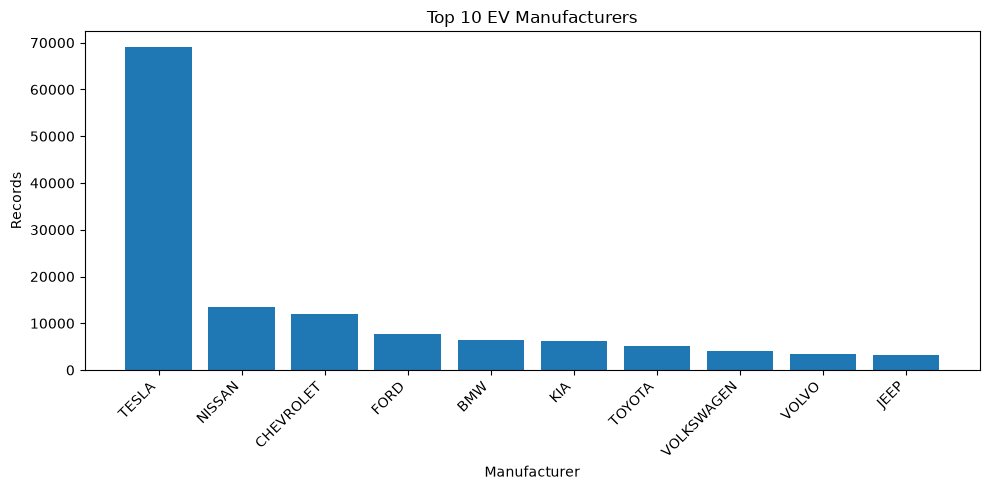

In [194]:
import matplotlib.pyplot as plt

q="""SELECT Make,COUNT(*) vehicles FROM ev_vehicles GROUP 
BY Make ORDER BY vehicles DESC LIMIT 10;"""
d=pd.read_sql_query(q,conn)
plt.figure(figsize=(10,5)); plt.bar(d.Make,d.vehicles); plt.title("Top 10 EV Manufacturers"); plt.xlabel("Manufacturer"); plt.ylabel("Records"); plt.xticks(rotation=45,ha="right"); plt.tight_layout(); plt.show()

### 192. EV type mix
**Business purpose:** Convert SQL results into an analyst-facing visual insight.

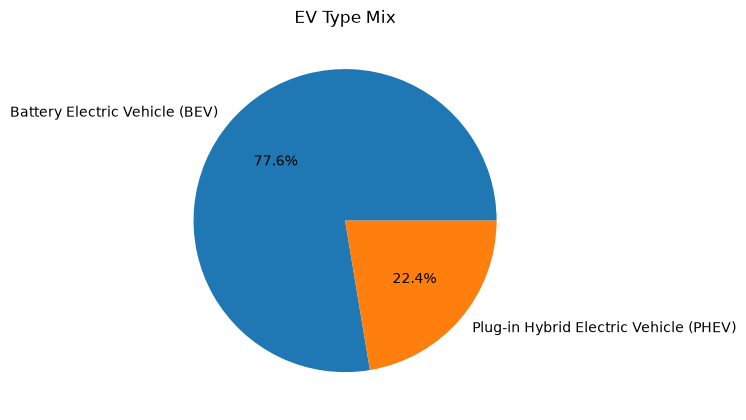

In [195]:
q="""SELECT EV_Type,COUNT(*) vehicles FROM ev_vehicles GROUP BY EV_Type ORDER BY vehicles DESC;"""
d=pd.read_sql_query(q,conn)
plt.figure(figsize=(7,7)); plt.pie(d.vehicles,labels=d.EV_Type,autopct="%1.1f%%"); plt.title("EV Type Mix"); plt.tight_layout(); plt.show()

### 193. EV records by model year
**Business purpose:** Convert SQL results into an analyst-facing visual insight.

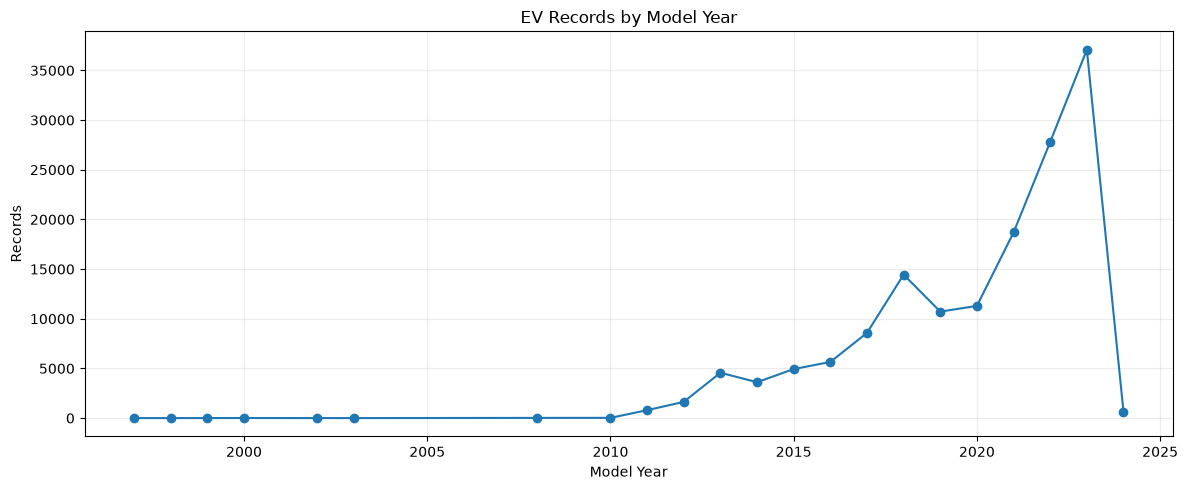

In [196]:
q="""SELECT Model_Year,COUNT(*) vehicles FROM ev_vehicles GROUP BY Model_Year ORDER BY Model_Year;"""
d=pd.read_sql_query(q,conn)
plt.figure(figsize=(12,5)); plt.plot(d.Model_Year,d.vehicles,marker="o"); plt.title("EV Records by Model Year"); plt.xlabel("Model Year"); plt.ylabel("Records"); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

### 194. Average range trend
**Business purpose:** Convert SQL results into an analyst-facing visual insight.

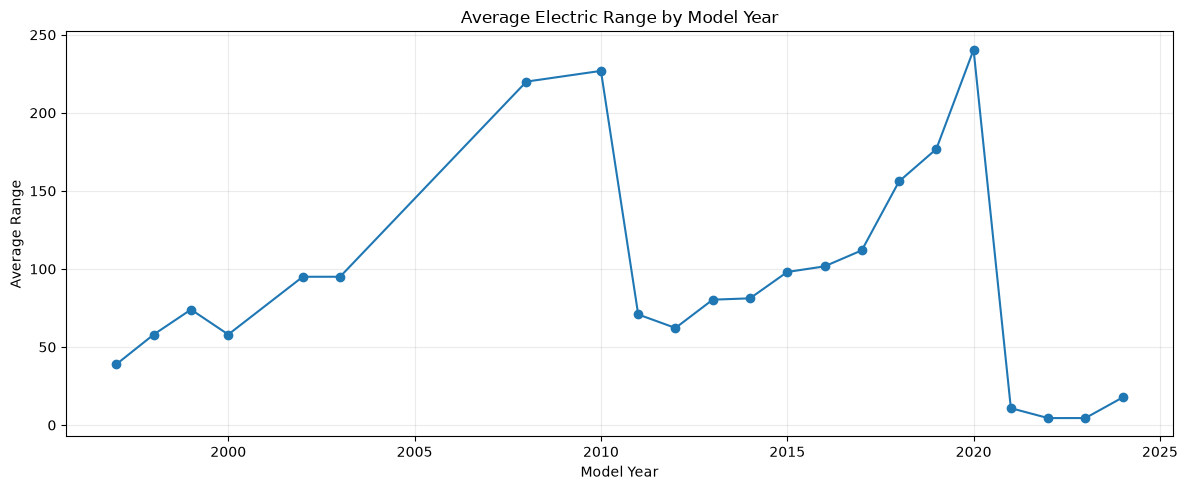

In [197]:
q="""SELECT Model_Year,AVG(Electric_Range) avg_range FROM ev_vehicles WHERE Electric_Range IS NOT NULL GROUP BY Model_Year ORDER BY Model_Year;"""
d=pd.read_sql_query(q,conn)
plt.figure(figsize=(12,5)); plt.plot(d.Model_Year,d.avg_range,marker="o"); plt.title("Average Electric Range by Model Year"); plt.xlabel("Model Year"); plt.ylabel("Average Range"); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

### 195. Average MSRP trend
**Business purpose:** Convert SQL results into an analyst-facing visual insight.

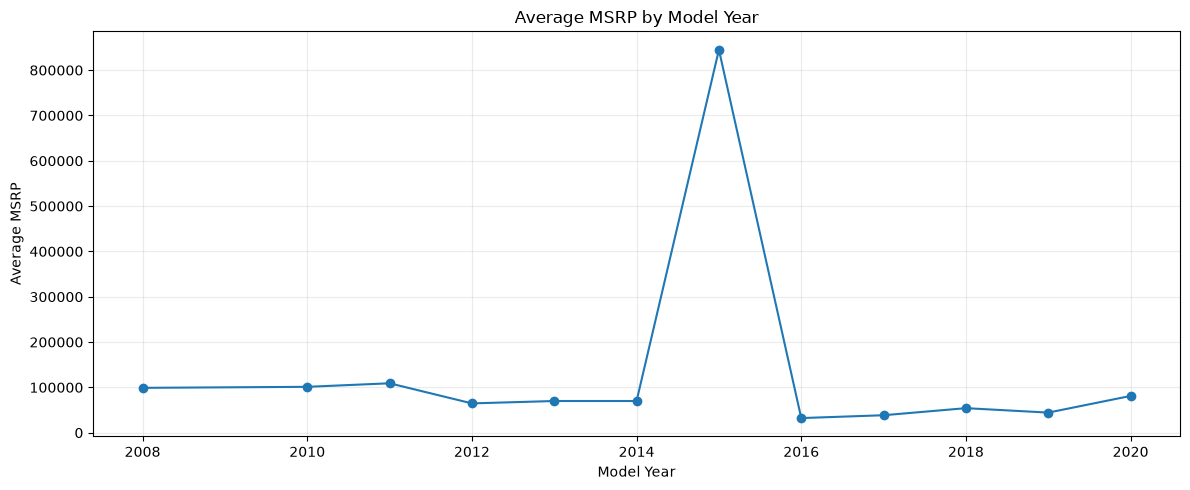

In [198]:
q="""SELECT Model_Year,AVG(Base_MSRP) avg_msrp FROM ev_vehicles WHERE Base_MSRP>0 GROUP BY Model_Year ORDER BY Model_Year;"""
d=pd.read_sql_query(q,conn)
plt.figure(figsize=(12,5)); plt.plot(d.Model_Year,d.avg_msrp,marker="o"); plt.title("Average MSRP by Model Year"); plt.xlabel("Model Year"); plt.ylabel("Average MSRP"); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

### 196. Range vs MSRP
**Business purpose:** Convert SQL results into an analyst-facing visual insight.

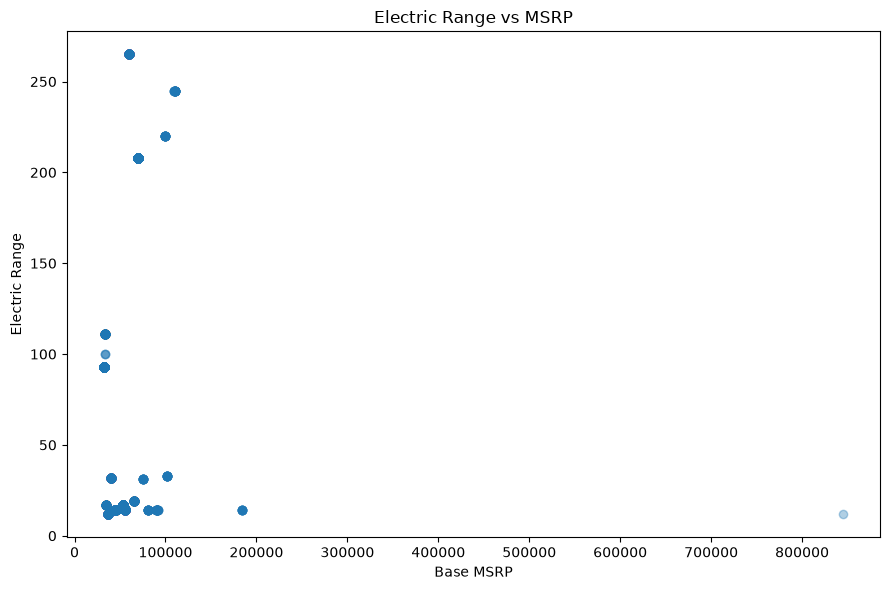

In [199]:
q="""SELECT Electric_Range,Base_MSRP FROM ev_vehicles WHERE Electric_Range IS NOT NULL AND Base_MSRP>0;"""
d=pd.read_sql_query(q,conn)
plt.figure(figsize=(9,6)); plt.scatter(d.Base_MSRP,d.Electric_Range,alpha=.35); plt.title("Electric Range vs MSRP"); plt.xlabel("Base MSRP"); plt.ylabel("Electric Range"); plt.tight_layout(); plt.show()

### 197. Top states
**Business purpose:** Convert SQL results into an analyst-facing visual insight.

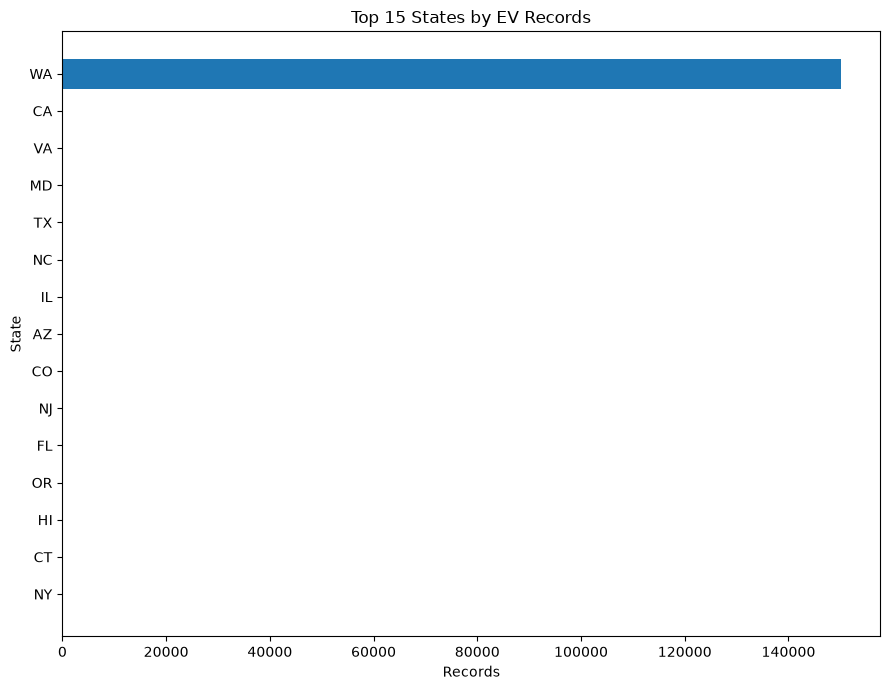

In [200]:
q="""SELECT State,COUNT(*) vehicles FROM ev_vehicles GROUP BY State ORDER BY vehicles DESC LIMIT 15;"""
d=pd.read_sql_query(q,conn).sort_values("vehicles")
plt.figure(figsize=(9,7)); plt.barh(d.State,d.vehicles); plt.title("Top 15 States by EV Records"); plt.xlabel("Records"); plt.ylabel("State"); plt.tight_layout(); plt.show()

### 198. Range category
**Business purpose:** Convert SQL results into an analyst-facing visual insight.

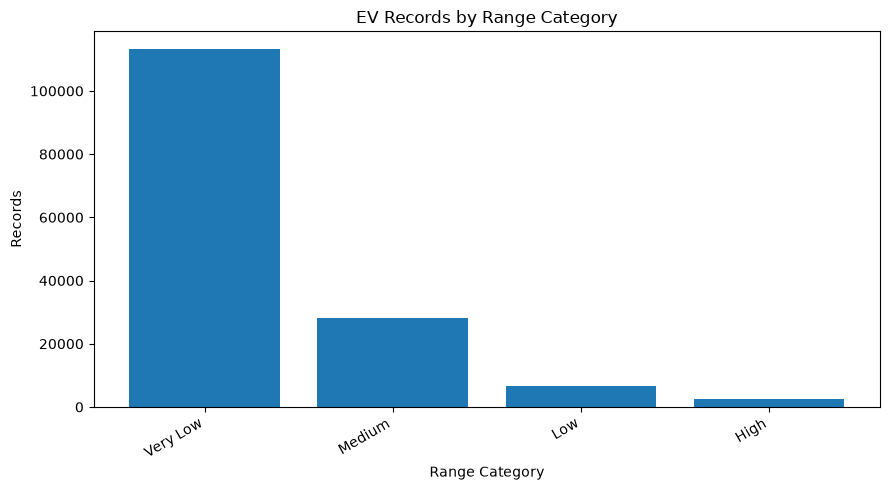

In [201]:
q="""SELECT Range_Category,COUNT(*) vehicles FROM ev_vehicles GROUP BY Range_Category ORDER BY vehicles DESC;"""
d=pd.read_sql_query(q,conn)
plt.figure(figsize=(9,5)); plt.bar(d.Range_Category.astype(str),d.vehicles); plt.title("EV Records by Range Category"); plt.xlabel("Range Category"); plt.ylabel("Records"); plt.xticks(rotation=30,ha="right"); plt.tight_layout(); plt.show()

### 199. Business segment
**Business purpose:** Convert SQL results into an analyst-facing visual insight.

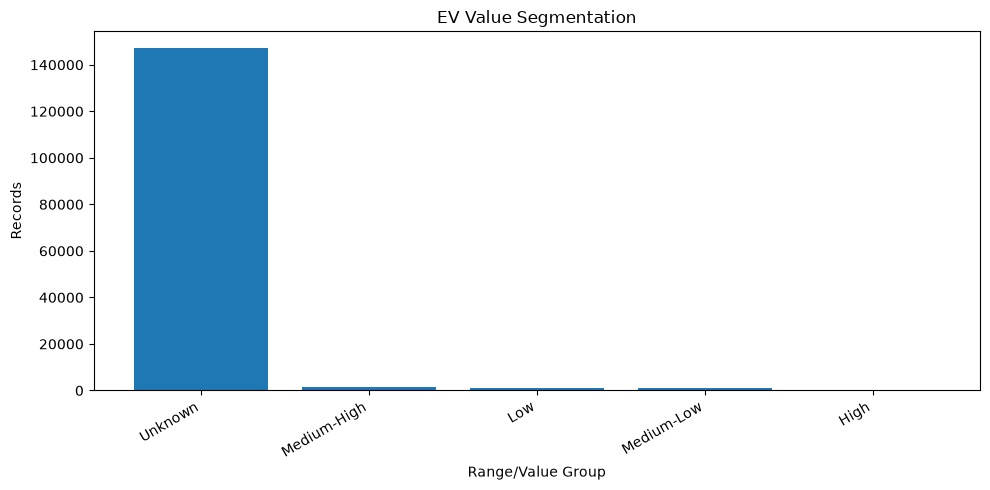

In [204]:
q="""SELECT Range_Value_Group,COUNT(*) vehicles FROM ev_vehicles GROUP BY Range_Value_Group ORDER BY vehicles DESC;"""
d=pd.read_sql_query(q,conn)

d["Range_Value_Group"]=d["Range_Value_Group"].fillna("Unknown").astype(str)

plt.figure(figsize=(10,5)); plt.bar(d["Range_Value_Group"],d["vehicles"]); plt.title("EV Value Segmentation"); plt.xlabel("Range/Value Group"); plt.ylabel("Records"); plt.xticks(rotation=30,ha="right"); plt.tight_layout(); plt.show()

### 200. Executive dashboard
**Business purpose:** Convert SQL results into an analyst-facing visual insight.

,total_records,manufacturers,models,states,avg_range,avg_msrp
0,150482,37,127,41,67.88,57172.04


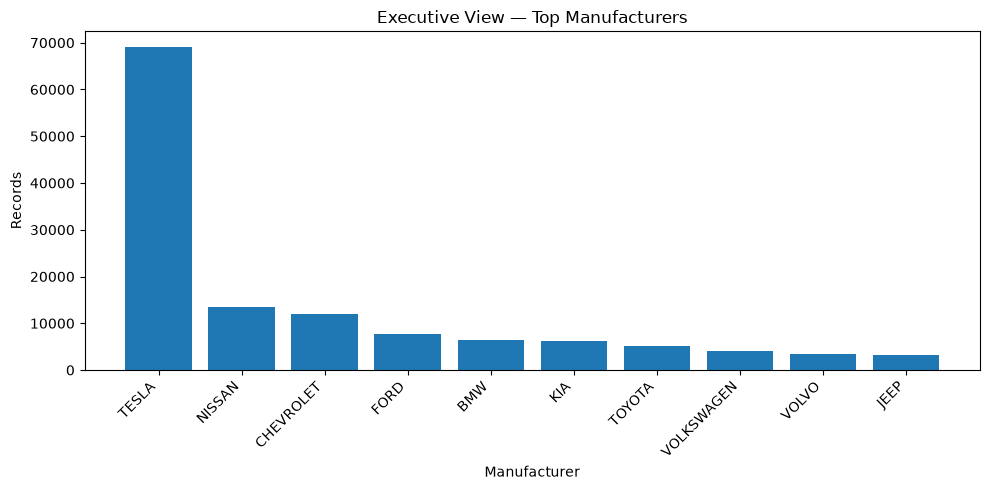

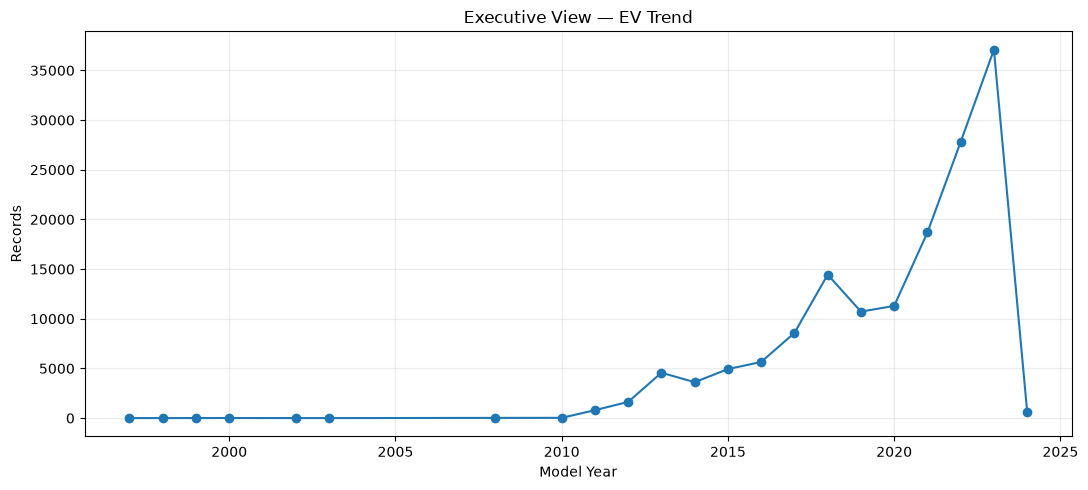

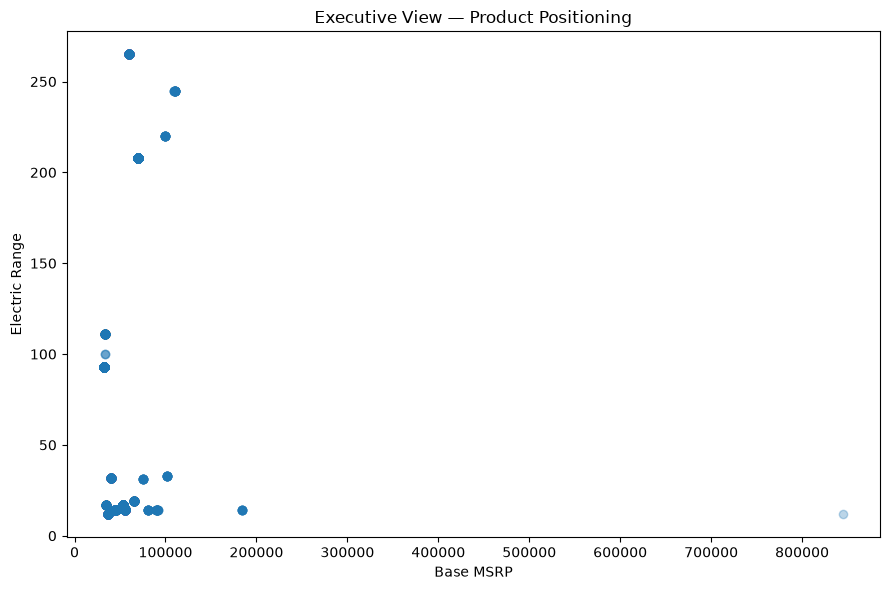

In [205]:
kpi=pd.read_sql_query("""SELECT COUNT(*) total_records,COUNT(DISTINCT Make) manufacturers,COUNT(DISTINCT Model) models,COUNT(DISTINCT State) states,ROUND(AVG(Electric_Range),2) avg_range,ROUND(AVG(NULLIF(Base_MSRP,0)),2) avg_msrp FROM ev_vehicles;""",conn)
display(kpi)

m=pd.read_sql_query("""SELECT Make,COUNT(*) vehicles FROM ev_vehicles GROUP BY Make ORDER BY vehicles DESC LIMIT 10;""",conn)
plt.figure(figsize=(10,5)); plt.bar(m.Make,m.vehicles); plt.title("Executive View — Top Manufacturers"); plt.xlabel("Manufacturer"); plt.ylabel("Records"); plt.xticks(rotation=45,ha="right"); plt.tight_layout(); plt.show()

y=pd.read_sql_query("""SELECT Model_Year,COUNT(*) vehicles FROM ev_vehicles GROUP BY Model_Year ORDER BY Model_Year;""",conn)
plt.figure(figsize=(11,5)); plt.plot(y.Model_Year,y.vehicles,marker="o"); plt.title("Executive View — EV Trend"); plt.xlabel("Model Year"); plt.ylabel("Records"); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

s=pd.read_sql_query("""SELECT Electric_Range,Base_MSRP FROM ev_vehicles WHERE Electric_Range IS NOT NULL AND Base_MSRP>0;""",conn)
plt.figure(figsize=(9,6)); plt.scatter(s.Base_MSRP,s.Electric_Range,alpha=.3); plt.title("Executive View — Product Positioning"); plt.xlabel("Base MSRP"); plt.ylabel("Electric Range"); plt.tight_layout(); plt.show()

# 7. Final Business Questions

After completing the notebook, document answers to:

1. Which manufacturers dominate the dataset?
2. Which states have the largest EV presence?
3. What is the BEV vs PHEV mix?
4. How has EV activity changed by model year?
5. How has average electric range changed?
6. How has average MSRP changed?
7. Which manufacturers offer strong range relative to price?
8. Which manufacturers have the broadest product portfolios?
9. Which geographic markets appear strongest?
10. What data-quality limitations should management know?

## Project deliverables

- SQLite database: `ev_analysis.db`
- This notebook: `EV_SQL_200_Commands_Complete_Book.ipynb`
- SQL business analysis
- Deep visual analysis
- Executive dashboard
- README / project report

In [206]:
conn.close()
print("SQLite connection closed.")

SQLite connection closed.
